# Graph RQ2 — Knowledge Graph vs Clustering Analysis

This notebook builds a heterogeneous Scholarly Knowledge Graph (SKG) of chess-research papers,
authors, and keywords, computes network centrality metrics (degree, PageRank, betweenness),
and then applies semantic clustering (KMeans, Leiden, HDBSCAN) on Qwen3 keyword embeddings.
The two approaches are compared across six measurable indicators to answer RQ2:
how do graph-based and cluster-based methods differ in identifying cross-era transitional research?

In [ ]:
from pathlib import Path
import ast
import os
from collections import defaultdict

import igraph as ig
import leidenalg
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import hdbscan
import umap
from scipy.stats import entropy
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler, normalize
from tqdm import tqdmplt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white"})

# Project-relative path variables — resolve from this script's location
OUTPUT_DIR = Path("..").resolve() / "output"
KW_DIR     = Path("..").resolve() / "keywords_results"
GRAPH_DIR  = OUTPUT_DIR / "graph"


    adjusted_mutual_info_score,
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)


Load the enriched metadata and normalised keyword CSV files into DataFrames.

In [31]:
meta = pd.read_csv(OUTPUT_DIR / "metadata_enriched_after_openalex_year.csv")
kw_df = pd.read_csv(KW_DIR / "keywords_normalized_deduplicated_no_stopwords.csv")

Parse keywords, assign historical eras, build the heterogeneous NetworkX graph, compute degree/PageRank/betweenness, and save graph metrics and the GEXF file.

In [ ]:
meta["filename"] = meta["pdf_file"].str.replace(".pdf", "", regex=False)

KEYWORDS_COLUMN = "keywords_normalized"
if KEYWORDS_COLUMN not in kw_df.columns:
    KEYWORDS_COLUMN = "keywords_without_stopwords"


def parse_keywords(raw_value):
    """Execute parse_keywords."""
    if pd.isna(raw_value):
        return []
    kws = ast.literal_eval(raw_value) if isinstance(raw_value, str) else raw_value
    if not isinstance(kws, (list, tuple)):
        return []
    parsed = []
    for item in kws:
        if not isinstance(item, (list, tuple)) or len(item) != 2:
            continue
        kw, strength = item
        kw = str(kw).strip()
        if not kw:
            continue
        parsed.append((kw, float(strength)))
    return parsed


def get_era(year) -> str:
    """Execute get_era."""
    if pd.isna(year):
        return "unknown_year"
    year = int(year)
    if 1950 <= year < 1977:
        return "1950-1977"
    if 1977 <= year < 1997:
        return "1977-1997"
    if 1997 <= year < 2017:
        return "1997-2017"
    if year >= 2017:
        return "2017+"
    return "before_1950"        

meta["_year_combined"] = meta["crossref_year"].combine_first(meta["original_year"]).combine_first(meta.get("openalex_year", pd.Series(dtype=float)))
meta["era"] = meta["_year_combined"].apply(get_era)

G = nx.Graph()

print("Adding papers")
for _, row in tqdm(meta.iterrows(), total=len(meta), desc="Papers"):
    G.add_node(row["filename"],
               type="Paper",
               title=str(row.get("original_title", "")),
               year=row.get("crossref_year"),
               era=row["era"])

# Add author nodes and edges
print("Adding authors")
for _, row in tqdm(meta.iterrows(), total=len(meta), desc="Authors"):
    authors_raw = str(row.get("crossref_authors") or row.get("original_authors", ""))
    if authors_raw and authors_raw != "nan":
        for author in authors_raw.split(";"):
            author = author.strip()
            if author:
                if not G.has_node(author):
                    G.add_node(author, type="Author")
                G.add_edge(row["filename"], author, rel="AUTHORED")

# Add keyword nodes and edges
print("Adding keywords")
for _, row in tqdm(kw_df.iterrows(), total=len(kw_df), desc="Keywords"):
    fname = row["filename"]
    kws = parse_keywords(row.get(KEYWORDS_COLUMN))
    for kw, strength in kws:
        if not G.has_node(kw):
            G.add_node(kw, type="Keyword")
        G.add_edge(fname, kw, rel="HAS_KEYWORD", weight=strength)

print(f"\nNodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Papers: {sum(1 for n,d in G.nodes(data=True) if d.get('type')=='Paper')}")
print(f"Authors: {sum(1 for n,d in G.nodes(data=True) if d.get('type')=='Author')}")
print(f"Keywords: {sum(1 for n,d in G.nodes(data=True) if d.get('type')=='Keyword')}")

print("\nComputing Degree")
degree = dict(G.degree())

print("Computing PageRank")
pagerank = nx.pagerank(G, alpha=0.85, weight="weight")

print("Computing Betweenness")

def betweenness_with_progress(G, weight="weight"):
    """Execute betweenness_with_progress."""
    nodes = list(G.nodes())
    n = len(nodes)
    betweenness = defaultdict(float)
    for source in tqdm(nodes, desc="Betweenness", total=n):
        paths = nx.single_source_dijkstra_path(G, source, weight=weight)
        for target, path in paths.items():
            if len(path) > 2:
                for mid in path[1:-1]:
                    betweenness[mid] += 1
    scale = 1.0 / ((n - 1) * (n - 2))
    for node in betweenness:
        betweenness[node] *= scale
    return dict(betweenness)

betweenness = betweenness_with_progress(G)

# Top authors and keywords
authors = [(n, pagerank[n]) for n, d in G.nodes(data=True)
           if d.get("type") == "Author" and "nan" not in n.lower()]
top_authors = sorted(authors, key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Authors by PageRank:")
for name, score in top_authors:
    print(f"  {name}: {score:.5f}")

keywords = [(n, degree[n]) for n, d in G.nodes(data=True) if d.get("type") == "Keyword"]
top_kw = sorted(keywords, key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Keywords by Degree:")
for kw, deg in top_kw:
    print(f"  {kw}: {deg}")

# Save metrics
print("\nSaving graph_metrics.csv")
rows = []
for node, data in tqdm(G.nodes(data=True), total=G.number_of_nodes(), desc="Saving metrics"):
    rows.append({
        "node": node,
        "type": data.get("type", ""),
        "era": data.get("era", ""),
        "year": data.get("year", ""),
        "degree": degree[node],
        "pagerank": pagerank[node],
        "betweenness": betweenness.get(node, 0.0)
    })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(OUTPUT_DIR / "graph/graph_metrics_full.csv", index=False)
print("graph_metrics.csv saved")

# Save graph for Gephi
print("Saving graph.gexf")
nx.write_gexf(G, OUTPUT_DIR / "graph/graph_full.gexf")
print("graph.gexf saved")

# Keywords by era
print("Computing keywords by era")
kw_era = defaultdict(lambda: defaultdict(float))
for u, v, data in tqdm(G.edges(data=True), total=G.number_of_edges(), desc="Keywords by era"):
    if data.get("rel") == "HAS_KEYWORD":
        paper = u if G.nodes[u].get("type") == "Paper" else v
        kw = v if G.nodes[u].get("type") == "Paper" else u
        era = G.nodes[paper].get("era", "Unknown")
        kw_era[kw][era] += data.get("weight", 1)

era_rows = []
for kw, eras in kw_era.items():
    for era, total_strength in eras.items():
        era_rows.append({"keyword": kw, "era": era, "total_strength": total_strength})

era_df = pd.DataFrame(era_rows)
era_df.to_csv(OUTPUT_DIR / "graph/top_keywords_by_era.csv", index=False)
print("top_keywords_by_era_full.csv saved")


Adding papers


Papers: 100%|██████████| 2376/2376 [00:00<00:00, 62666.51it/s]


Adding authors


Authors: 100%|██████████| 2376/2376 [00:00<00:00, 68857.43it/s]


Adding keywords


...


Top 10 Authors by PageRank:
  Jonathan Schaeffer: 0.00004
  Merim Bilalić: 0.00004
  Paolo Ciancarini: 0.00003
  Matej Guid: 0.00003
  Guillermo Campitelli: 0.00003
  Ivan Bratko: 0.00003
  Neil Charness: 0.00003
  Alan Turing: 0.00003
  Guy Haworth: 0.00003
  G.McC. Haworth: 0.00002

Top 10 Keywords by Degree:
  search extension: 33
  move: 33
  cognitive load: 33
  search process: 33
  backward induction: 33
  tournament: 33
  heuristic function: 33
  computational complexity: 33
  backgammon: 32
  domain knowledge: 32

Saving graph_metrics.csv


Saving metrics: 100%|██████████| 38535/38535 [00:00<00:00, 1705849.19it/s]


graph_metrics.csv saved
Saving graph.gexf
graph.gexf saved
Computing keywords by era


Keywords by era: 100%|██████████| 69825/69825 [00:00<00:00, 958166.02it/s]

top_keywords_by_era_full.csv saved


### Processing Steps Overview

1. **Load** keyword CSV (`keywords_normalized.csv`)
2. **Collect** all unique keywords from the corpus
3. **Embed** each unique keyword with a sentence-transformer model (~30–60 min)
4. **Aggregate** per-paper: compute the strength-weighted mean of its keyword vectors
5. **Matrix** shape: n_papers × embedding_dim
6. **Elbow / Silhouette** — choose optimal k
7. **K-Means** — assign papers to clusters
8. **Save** paper → cluster mapping


Deduplicate keywords per paper, parse raw keyword lists, and build the cleaned `kw_df_clean` lookup used throughout the embedding pipeline.

In [33]:
def dedup_keywords(kws_list):
    """Execute dedup_keywords."""
    seen = defaultdict(list)
    for kw, strength in kws_list:
        seen[kw].append(strength)
    return [(kw, sum(vals) / len(vals)) for kw, vals in seen.items()]

KEYWORDS_COLUMN = "keywords_normalized"
if KEYWORDS_COLUMN not in kw_df.columns:
    KEYWORDS_COLUMN = "keywords_without_stopwords"


def parse_keywords(raw_value):
    """Execute parse_keywords."""
    if pd.isna(raw_value):
        return []
    kws = ast.literal_eval(raw_value) if isinstance(raw_value, str) else raw_value
    if not isinstance(kws, (list, tuple)):
        return []
    parsed = []
    for item in kws:
        if not isinstance(item, (list, tuple)) or len(item) != 2:
            continue
        kw, strength = item
        kw = str(kw).strip()
        if not kw:
            continue
        parsed.append((kw, float(strength)))
    return parsed

kw_df_clean = []
for _, row in kw_df.iterrows():
    kws = parse_keywords(row.get(KEYWORDS_COLUMN))
    if not kws:
        continue
    kws_dedup = dedup_keywords(kws)
    kw_df_clean.append({"filename": row["filename"], "keywords": kws_dedup})

print(f"Papers processed: {len(kw_df_clean)}")

Papers processed: 2360


Collect the set of all unique keywords across the corpus — this is the vocabulary that will be embedded.

In [34]:
all_kws = list({kw for row in kw_df_clean for kw, _ in row["keywords"]})
print(f"Unique keywords: {len(all_kws)}")

Unique keywords: 33868


Load the Qwen3-Embedding-0.6B sentence-transformer model.

In [37]:
model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
print("Model loaded!")

Loading weights: 100%|██████████| 310/310 [00:00<00:00, 1193.52it/s]


Model loaded!


Batch-encode every unique keyword into a dense vector and store the embeddings in `kw_embeddings`.

In [38]:
# Compute embeddings
BATCH_SIZE = 512
kw_embeddings = {}

for i in tqdm(range(0, len(all_kws), BATCH_SIZE), desc="Embedding keywords"):
    batch = all_kws[i:i + BATCH_SIZE]
    vecs = model.encode(batch, batch_size=BATCH_SIZE, convert_to_numpy=True)
    for kw, vec in zip(batch, vecs):
        kw_embeddings[kw] = vec

print(f"Embeddings computed: {len(kw_embeddings)}")

Embedding keywords: 100%|██████████| 67/67 [00:16<00:00,  4.00it/s]

Embeddings computed: 33868


In [39]:
np.save("kw_embeddings_keys.npy", np.array(list(kw_embeddings.keys())))
np.save("kw_embeddings_vecs.npy", np.array(list(kw_embeddings.values())))
print("Embeddings saved")

Embeddings saved


Persist keyword embeddings to disk so they can be reloaded without re-running the slow encoding step.

In [40]:
keys = np.load("kw_embeddings_keys.npy", allow_pickle=True)
vecs = np.load("kw_embeddings_vecs.npy")
kw_embeddings = dict(zip(keys, vecs))
print(f"Embeddings loaded: {len(kw_embeddings)}")

Embeddings loaded: 33868


Reload keyword embeddings from disk and reconstruct the `kw_embeddings` dictionary.

In [41]:
paper_vectors = []
paper_filenames = []

for row in tqdm(kw_df_clean, desc="Building paper vectors"):
    vecs, weights = [], []
    for kw, strength in row["keywords"]:
        if kw in kw_embeddings:
            vecs.append(kw_embeddings[kw])
            weights.append(strength)
    if vecs:
        paper_vec = np.average(np.array(vecs), axis=0, weights=np.array(weights))
        paper_vectors.append(paper_vec)
        paper_filenames.append(row["filename"])

paper_matrix = np.array(paper_vectors)
print(f"Paper matrix shape: {paper_matrix.shape}")

Building paper vectors: 100%|██████████| 2360/2360 [00:00<00:00, 22154.63it/s]

Paper matrix shape: (2360, 1024)


Build the per-paper embedding matrix by taking the strength-weighted average of each paper's keyword vectors.

### K Selection: Multi-metric consensus
Silhouette · Calinski-Harabasz · Davies-Bouldin · Stability (AMI) · External ARI vs eras — all on the same UMAP 50D space used for actual clustering.

Scanning k: 100%|██████████| 14/14 [00:04<00:00,  3.35it/s]



=== Best k by composite score: k=13 ===
 k  silhouette  calinski_harabasz  davies_bouldin  ari_era  stability  composite
 2    0.305819        1059.008433        1.369906 0.015480   0.998015   0.397124
 3    0.341612        1363.168470        1.028598 0.000530   1.000000   0.483140
 4    0.400251        1428.169737        0.957512 0.014943   0.993950   0.813030
 5    0.383587        1465.567808        0.844419 0.009447   0.985598   0.753085
 6    0.390445        1436.326035        0.831072 0.003689   0.957939   0.643273
 7    0.400510        1477.003538        0.850689 0.005174   0.939695   0.659245
 8    0.380303        1534.564076        0.896318 0.010631   0.970969   0.744718
 9    0.400279        1581.559919        0.882950 0.013600   0.983058   0.855451
10    0.395346        1589.587093        0.861570 0.010306   0.861955   0.638079
11    0.411056        1658.608807        0.859524 0.011170   0.980935   0.871092
12    0.409317        1662.857347        0.846664 0.010538   0.97980

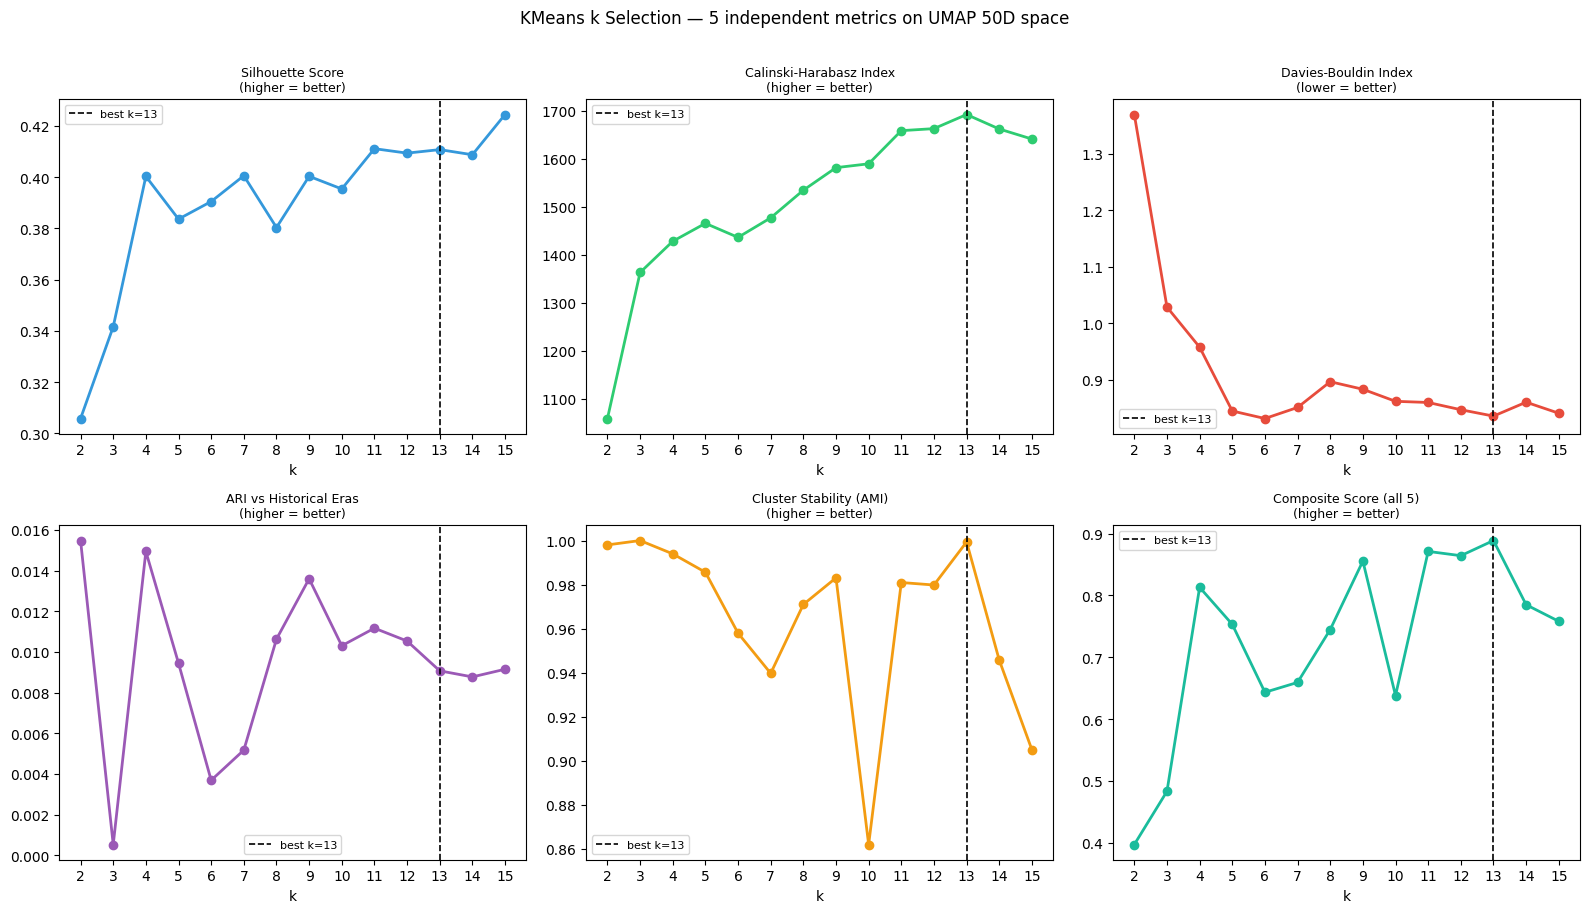

Saved: /home/john/repos/leno4ka/output/graph/k_selection_all_metrics.png

Fitting KMeans with best_k=13...
Saved paper_clusters.csv  (k=13, 2360 papers)
Saved kmeans_centroids.npy
cluster
0     254
1     277
2     131
3     219
4      79
5     192
6     120
7     182
8     240
9     263
10     85
11    186
12    132
Name: count, dtype: int64


In [ ]:
# ============================================================
# K SELECTION: Multi-metric consensus on UMAP 50D space
# Silhouette · Calinski-Harabasz · Davies-Bouldin
#   + Cluster stability (AMI across 10 seeds)
#   + External validation: ARI vs historical eras
# Run AFTER cell 18 (paper_50d must exist).
# ============================================================

# ── guard: load paper_50d from disk if kernel was restarted or arrays are misaligned ──
try:
    _aligned = len(paper_filenames) > 0 and len(paper_filenames) == len(paper_50d)
except NameError:
    _aligned = False
if not _aligned:
    paper_50d = np.load(GRAPH_DIR / "paper_50d.npy")
    _fn_path  = GRAPH_DIR / "paper_filenames.npy"
    if os.path.exists(_fn_path):
        paper_filenames = np.load(_fn_path, allow_pickle=True).tolist()
    else:
        _cl = pd.read_csv(GRAPH_DIR / "paper_clusters.csv")
        paper_filenames = _cl["filename"].tolist()
    if len(paper_filenames) != len(paper_50d):
        raise RuntimeError(
            f"paper_filenames ({len(paper_filenames)}) and paper_50d "
            f"({len(paper_50d)}) have different lengths. "
            "Re-run the cells that build paper_matrix and paper_50d (cells 12/18 + UMAP)."
        )

# ── era labels aligned to paper order ────────────────────────────────────
ERA_TO_INT = {"before_1950": 0, "1950-1977": 1, "1977-1997": 2,
              "1997-2017": 3, "2017+": 4, "unknown_year": -1}
_meta = pd.read_csv(OUTPUT_DIR / "metadata_enriched_after_openalex_year.csv")
_meta["filename"] = _meta["pdf_file"].str.replace(".pdf", "", regex=False)

def _get_era(year):
    """Execute _get_era."""
    if pd.isna(year): 
        return "unknown_year"
    y = int(year)
    if y < 1950:  
        return "before_1950"
    if y < 1977:  
        return "1950-1977"
    if y < 1997:  
        return "1977-1997"
    if y < 2017:  
        return "1997-2017"
    return "2017+"

_meta["_year_combined"] = _meta["crossref_year"].combine_first(_meta["original_year"]).combine_first(_meta.get("openalex_year", pd.Series(dtype=float)))
_meta["era"] = _meta["_year_combined"].apply(_get_era)
_era_map = _meta.set_index("filename")["era"].to_dict()
era_labels = np.array([ERA_TO_INT.get(_era_map.get(f, "unknown_year"), -1)
                        for f in paper_filenames])
known_mask = era_labels != -1          # exclude papers with unknown year from ARI


# ── scan k ───────────────────────────────────────────────────────────────
K_MIN, K_MAX, N_SEEDS = 2, 15, 10
results = []

for k in tqdm(range(K_MIN, K_MAX + 1), desc="Scanning k"):
    # Primary metrics (deterministic seed=42)
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(paper_50d)

    sil = silhouette_score(paper_50d, labels, sample_size=min(500, len(paper_50d)))
    ch  = calinski_harabasz_score(paper_50d, labels)
    db  = davies_bouldin_score(paper_50d, labels)

    # External validation: ARI vs historical eras (known-year papers only)
    ari_era = adjusted_rand_score(era_labels[known_mask], labels[known_mask])

    # Stability: AMI between seed=42 and 9 other seeds
    ami_scores = []
    for seed in range(1, N_SEEDS + 1):
        km2 = KMeans(n_clusters=k, random_state=seed * 7, n_init=10)
        lbl2 = km2.fit_predict(paper_50d)
        ami_scores.append(adjusted_mutual_info_score(labels, lbl2))
    stability = float(np.mean(ami_scores))

    results.append(dict(k=k, silhouette=sil, calinski_harabasz=ch,
                        davies_bouldin=db, ari_era=ari_era, stability=stability))

df_k = pd.DataFrame(results)
df_k.to_csv(GRAPH_DIR / "k_selection_metrics.csv", index=False)

# ── normalise for composite score (CH higher=better, DB lower=better) ────
_sc = MinMaxScaler()
df_k["sil_n"]      = _sc.fit_transform(df_k[["silhouette"]])
df_k["ch_n"]       = _sc.fit_transform(df_k[["calinski_harabasz"]])
df_k["db_n"]       = 1 - _sc.fit_transform(df_k[["davies_bouldin"]])  # invert
df_k["ari_n"]      = _sc.fit_transform(df_k[["ari_era"]])
df_k["stab_n"]     = _sc.fit_transform(df_k[["stability"]])
df_k["composite"]  = df_k[["sil_n", "ch_n", "db_n", "ari_n", "stab_n"]].mean(axis=1)

best_k = int(df_k.loc[df_k["composite"].idxmax(), "k"])
print(f"\n=== Best k by composite score: k={best_k} ===")
print(df_k[["k","silhouette","calinski_harabasz","davies_bouldin",
            "ari_era","stability","composite"]].to_string(index=False))

# ── plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metrics = [
    ("silhouette",        "Silhouette Score",          "higher = better", "#3498db"),
    ("calinski_harabasz", "Calinski-Harabasz Index",   "higher = better", "#2ecc71"),
    ("davies_bouldin",    "Davies-Bouldin Index",      "lower = better",  "#e74c3c"),
    ("ari_era",           "ARI vs Historical Eras",    "higher = better", "#9b59b6"),
    ("stability",         "Cluster Stability (AMI)",   "higher = better", "#f39c12"),
    ("composite",         "Composite Score (all 5)",   "higher = better", "#1abc9c"),
]
for ax, (col, title, note, color) in zip(axes.flat, metrics):
    ax.plot(df_k["k"], df_k[col], marker="o", color=color, linewidth=2)
    ax.axvline(best_k, color="black", linestyle="--", linewidth=1.2,
               label=f"best k={best_k}")
    ax.set_title(f"{title}\n({note})", fontsize=9)
    ax.set_xlabel("k"); ax.set_xticks(range(K_MIN, K_MAX + 1))
    ax.legend(fontsize=8)

plt.suptitle("KMeans k Selection — 5 independent metrics on UMAP 50D space",
             fontsize=12, y=1.01)
plt.tight_layout()
out = GRAPH_DIR / "k_selection_all_metrics.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")


# ── fit final KMeans with best_k and save paper_clusters.csv ─────────────
print(f"\nFitting KMeans with best_k={best_k}...")
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(paper_50d)

cluster_df_out = pd.DataFrame({"filename": paper_filenames, "cluster": cluster_labels})
cluster_df_out.to_csv(GRAPH_DIR / "paper_clusters.csv", index=False)
np.save(GRAPH_DIR / "kmeans_centroids.npy", km_final.cluster_centers_)
np.save(GRAPH_DIR / "paper_filenames.npy", np.array(paper_filenames))

# expose in kernel scope for downstream cells
kmeans = km_final

print(f"Saved paper_clusters.csv  (k={best_k}, {len(cluster_df_out)} papers)")
print("Saved kmeans_centroids.npy")
print(cluster_df_out["cluster"].value_counts().sort_index())

Fit final KMeans with the composite-optimal k and write `paper_clusters.csv`, `kmeans_centroids.npy`, and `paper_filenames.npy`.

In [44]:
def dedup_keywords(kws_list):
    """Execute dedup_keywords."""
    seen = defaultdict(list)
    for kw, strength in kws_list:
        seen[kw].append(strength)
    return [(kw, sum(vals) / len(vals)) for kw, vals in seen.items()]

KEYWORDS_COLUMN = "keywords_normalized"
if KEYWORDS_COLUMN not in kw_df.columns:
    KEYWORDS_COLUMN = "keywords_without_stopwords"


def parse_keywords(raw_value):
    """Execute parse_keywords."""
    if pd.isna(raw_value):
        return []
    kws = ast.literal_eval(raw_value) if isinstance(raw_value, str) else raw_value
    if not isinstance(kws, (list, tuple)):
        return []
    parsed = []
    for item in kws:
        if not isinstance(item, (list, tuple)) or len(item) != 2:
            continue
        kw, strength = item
        kw = str(kw).strip()
        if not kw:
            continue
        parsed.append((kw, float(strength)))
    return parsed

kw_df_clean = []
for _, row in kw_df.iterrows():
    kws = parse_keywords(row.get(KEYWORDS_COLUMN))
    if not kws:
        continue
    kws_dedup = dedup_keywords(kws)
    kw_df_clean.append({"filename": row["filename"], "keywords": kws_dedup})

paper_vectors = []
paper_filenames = []

for row in tqdm(kw_df_clean, desc="Rebuilding paper matrix"):
    vecs_list, weights = [], []
    for kw, strength in row["keywords"]:
        if kw in kw_embeddings:
            vecs_list.append(kw_embeddings[kw])
            weights.append(strength)
    if vecs_list:
        paper_vec = np.average(np.array(vecs_list), axis=0, weights=np.array(weights))
        paper_vectors.append(paper_vec)
        paper_filenames.append(row["filename"])

paper_matrix = np.array(paper_vectors)
print(f"paper_matrix restored: {paper_matrix.shape}")


Rebuilding paper matrix: 100%|██████████| 2360/2360 [00:00<00:00, 20819.65it/s]

paper_matrix restored: (2360, 1024)


Rebuild `kw_df_clean` and `paper_matrix` from scratch (useful after kernel restart) and restore the 50-D UMAP space.

In [45]:
# Leiden clustering (no fixed number of clusters)

# Build a kNN graph from paper embeddings
n_neighbors = 15
resolution = 1.0  # higher => more communities, lower => fewer

nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine")
nbrs.fit(paper_50d)
distances, indices = nbrs.kneighbors(paper_50d)

G_leiden = nx.Graph()
G_leiden.add_nodes_from(range(len(paper_50d)))

for i in range(len(paper_50d)):
    for d, j in zip(distances[i], indices[i]):
        if i == j:
            continue
        sim = max(0.0, 1.0 - float(d))
        if sim <= 0:
            continue
        if G_leiden.has_edge(i, j):
            if sim > G_leiden[i][j]["weight"]:
                G_leiden[i][j]["weight"] = sim
        else:
            G_leiden.add_edge(i, j, weight=sim)

# Convert to igraph for leidenalg
ig_graph = ig.Graph.from_networkx(G_leiden)
weights = [G_leiden[u][v]["weight"] for u, v in G_leiden.edges()]

partition = leidenalg.find_partition(
    ig_graph,
    leidenalg.RBConfigurationVertexPartition,
    weights=weights,
    resolution_parameter=resolution,
    seed=42,
    n_iterations=-1,
)

leiden_labels = np.full(len(paper_50d), -1, dtype=int)
for cid, community in enumerate(partition):
    for node_id in community:
        leiden_labels[node_id] = cid

leiden_df = pd.DataFrame({
    "filename": paper_filenames,
    "leiden_cluster": leiden_labels,
})

print(f"Leiden communities found: {len(partition)}")
print("Community sizes:")
print(leiden_df["leiden_cluster"].value_counts().sort_index())

leiden_df.to_csv(GRAPH_DIR / "paper_clusters_leiden.csv", index=False)
print(f"Saved: {GRAPH_DIR / 'paper_clusters_leiden.csv'}")

Leiden communities found: 30
Community sizes:
leiden_cluster
0     172
1     165
2     149
3     142
4     134
5     115
6     110
7     106
8     105
9     101
10     94
11     91
12     90
13     85
14     72
15     68
16     59
17     59
18     52
19     51
20     48
21     45
22     41
23     40
24     39
25     37
26     30
27     21
28     20
29     19
Name: count, dtype: int64
Saved: /home/john/repos/leno4ka/output/graph/paper_clusters_leiden.csv


Run Leiden community detection on a cosine-kNN graph of paper embeddings and save the resulting cluster assignments.

In [46]:
# Build human-readable labels for Leiden communities
leiden_df = pd.read_csv(OUTPUT_DIR / "graph/paper_clusters_leiden.csv")

# filename -> keywords lookup
kw_lookup = {row["filename"]: row["keywords"] for row in kw_df_clean}

cluster_keywords = defaultdict(lambda: defaultdict(float))
for _, row in leiden_df.iterrows():
    fname = row["filename"]
    cluster_id = row["leiden_cluster"]
    if fname not in kw_lookup:
        continue
    for kw, strength in kw_lookup[fname]:
        cluster_keywords[cluster_id][kw] += float(strength)

rows = []
for cluster_id in sorted(cluster_keywords):
    ranked = sorted(cluster_keywords[cluster_id].items(), key=lambda x: x[1], reverse=True)
    top10 = ranked[:10]
    top3 = [kw for kw, _ in top10[:3]]

    suggested_name = " / ".join(top3) if top3 else f"Cluster {cluster_id}"

    rows.append({
        "leiden_cluster": cluster_id,
        "suggested_name": suggested_name,
        "size": int((leiden_df["leiden_cluster"] == cluster_id).sum()),
        "top_keywords": "; ".join([kw for kw, _ in top10]),
    })

labels_df = pd.DataFrame(rows).sort_values(by=["size", "leiden_cluster"], ascending=[False, True])
output_path = OUTPUT_DIR / "graph/leiden_cluster_labels.csv"
labels_df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(labels_df.head(10).to_string(index=False))

Saved: /home/john/repos/leno4ka/output/graph/leiden_cluster_labels.csv
 leiden_cluster                                                          suggested_name  size                                                                                                                                                                                                     top_keywords
              0                         proof-number search / null-window search / ss s   172                                                                proof-number search; null-window search; ss s; minimax value; search extension; heuristic function; mtd(f); null-move search; cut-node; leaf node
              1                                  fixation / search process / chunk size   165                                                     fixation; search process; chunk size; mental imagery; eye movements; discrimination net; production system; retrieval structure; chess chunks; visual memory
              2     

Derive human-readable Leiden community labels from top-weighted keywords and save `leiden_cluster_labels.csv`.

In [47]:
try:
    _ = cluster_df
except NameError:
    cluster_df = pd.read_csv(GRAPH_DIR / "paper_clusters.csv")

def get_era(year) -> str:
    """Execute get_era."""
    if pd.isna(year):
        return "unknown_year"
    year = int(year)
    if 1950 <= year < 1977:
        return "1950-1977"
    if 1977 <= year < 1997:
        return "1977-1997"
    if 1997 <= year < 2017:
        return "1997-2017"
    if year >= 2017:
        return "2017+"
    return "before_1950"

meta["_year_combined"] = meta["crossref_year"].combine_first(meta["original_year"]).combine_first(meta.get("openalex_year", pd.Series(dtype=float)))
meta["era"] = meta["_year_combined"].apply(get_era)
meta["filename"] = meta["pdf_file"].str.replace(".pdf", "", regex=False)

# Safe merge: avoid duplicate era columns on repeated runs
cluster_df = cluster_df.drop(columns=["era"], errors="ignore")
cluster_df = cluster_df.merge(meta[["filename", "era"]], on="filename", how="left")
cluster_df["era"] = cluster_df["era"].fillna("unknown_year")

# Support both K-Means and Leiden result frames
cluster_col = "cluster" if "cluster" in cluster_df.columns else "leiden_cluster"

print("Cluster × Era distribution")
crosstab = pd.crosstab(cluster_df[cluster_col], cluster_df["era"])
print(crosstab)
crosstab.to_csv(OUTPUT_DIR / "graph/cluster_era_distribution.csv")

print("\n Top keywords per cluster")
kw_lookup = {row["filename"]: row["keywords"] for row in kw_df_clean}

cluster_keywords = defaultdict(lambda: defaultdict(float))
for _, row in cluster_df.iterrows():
    fname = row["filename"]
    cluster = row[cluster_col]
    if fname in kw_lookup:
        for kw, strength in kw_lookup[fname]:
            cluster_keywords[cluster][kw] += strength

top_kw_per_cluster = {}
for cluster, kws in sorted(cluster_keywords.items()):
    top5 = sorted(kws.items(), key=lambda x: x[1], reverse=True)[:5]
    top_kw_per_cluster[cluster] = top5
    print(f"\nCluster {cluster}:")
    for kw, score in top5:
        print(f"  {kw}: {score:.2f}")

Cluster × Era distribution
era      1950-1977  1977-1997  1997-2017  2017+  before_1950  unknown_year
cluster                                                                   
0                7         15        118     57            6            51
1               12         56        121     38            0            50
2                1          5         68     35            1            21
3                2         11        111     65            0            30
4                0          1         43     22            0            13
5                4         25        107     26            0            30
6                0          4         65     38            0            13
7                3         45         78     19            1            36
8                1         38        110     50            1            40
9               10         27        121     50            1            54
10               4          6         39     16            2            1

Merge cluster assignments with era metadata, print the cluster-by-era crosstab, and summarise top keywords per cluster.

In [48]:
metrics_df = pd.read_csv(OUTPUT_DIR / "graph/graph_metrics_full.csv")
papers_metrics = metrics_df[metrics_df["type"] == "Paper"].copy()

comparison_df = papers_metrics.merge(cluster_df[["filename", "cluster"]],
                                      left_on="node", right_on="filename", how="inner")

print(f"Papers in comparison: {len(comparison_df)}")


print("\n Top-10 papers by Betweenness (graph)")
top_between = comparison_df.nlargest(10, "betweenness")[["node", "era", "cluster", "betweenness"]]
print(top_between.to_string(index=False))

print("\n Avg graph metrics per cluster")
agg = comparison_df.groupby("cluster")[["degree", "pagerank", "betweenness"]].mean()
print(agg.round(6))


era_to_int = {
    "before_1950": 0,
    "1950-1977": 1,
    "1977-1997": 2,
    "1997-2017": 3,
    "2017+": 4,
    "unknown_year": 5,
}
comparison_df["era_int"] = comparison_df["era"].map(era_to_int)
comparison_df_clean = comparison_df.dropna(subset=["era_int"])

ari = adjusted_rand_score(comparison_df_clean["era_int"],
                           comparison_df_clean["cluster"])
print(f"\nAdjusted Rand Index (cluster vs era): {ari:.4f}")
print("(1.0 = perfect match, 0 = random, >0.3 = moderate agreement)")

comparison_df.to_csv(OUTPUT_DIR / "graph/rq3_comparison.csv", index=False)
print("\nrq3_comparison.csv saved")


Papers in comparison: 2360

 Top-10 papers by Betweenness (graph)
                                                       node          era  cluster  betweenness
                                                  98Metzner    1997-2017        0     0.044875
                                                06Leonard b        2017+       10     0.043485
                                                   01Hirsch    1997-2017        0     0.032561
            12Romportl(ed) - Beyond Artificial Intelligence unknown_year        8     0.022342
98Moravec When will computer hardware match the human brain unknown_year        8     0.018922
                                               94AlbertHeld unknown_year        8     0.015800
                                                 88Lonergan    1997-2017        0     0.015365
                                                    00Cowan    1997-2017        5     0.015173
                                                    88Reddy    1997-2017       

### t-SNE 2D Visualization (cluster-based methods)
t-SNE with `perplexity=40` tends to produce tighter, more visually separated clusters than UMAP for this corpus size.

Running t-SNE (2D)...
t-SNE coords saved.
KMeans k=13 | Leiden communities=30 (emergent, not controlled by best_k)


/tmp/ipykernel_252297/2859877273.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(1, n_clusters))


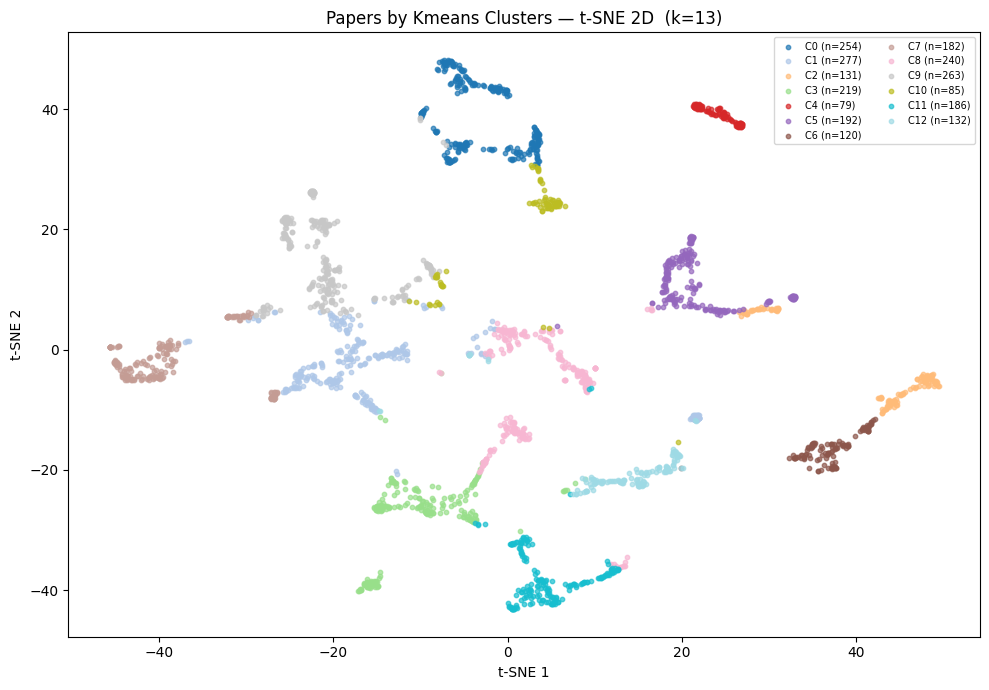

Saved: /home/john/repos/leno4ka/output/graph/rq3_kmeans_clusters_tsne2d.png


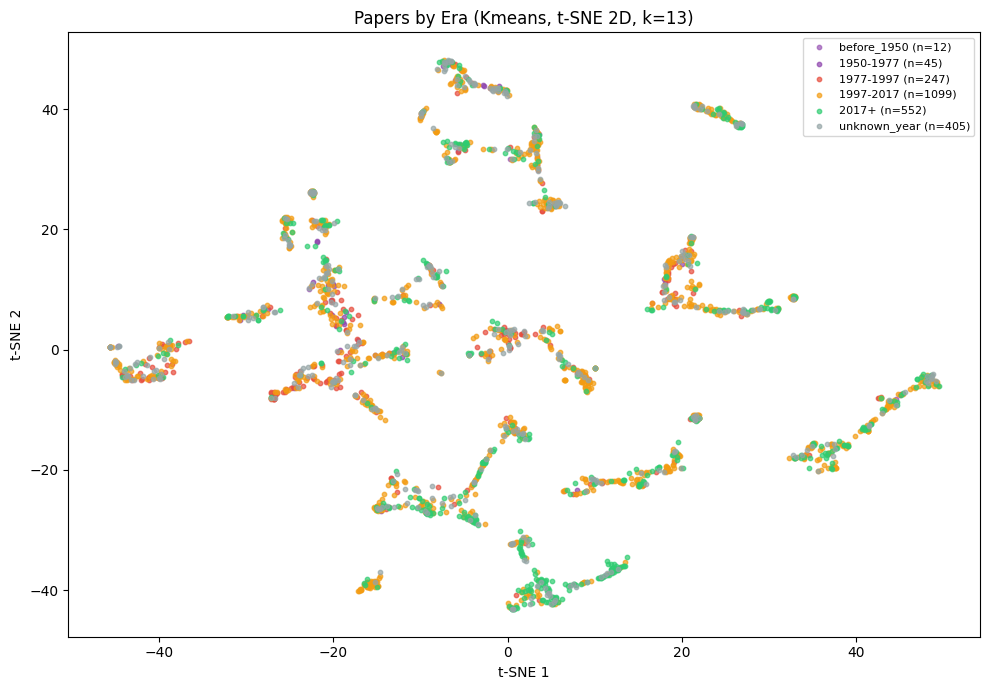

Saved: /home/john/repos/leno4ka/output/graph/rq3_kmeans_era_tsne2d.png


/tmp/ipykernel_252297/2859877273.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(1, n_clusters))


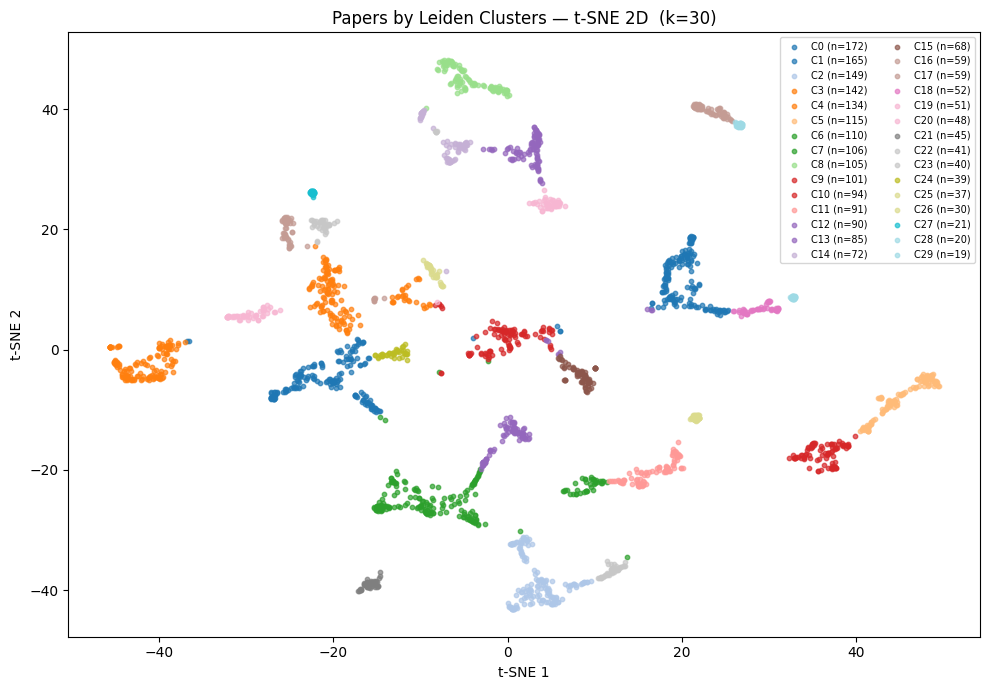

Saved: /home/john/repos/leno4ka/output/graph/rq3_leiden_clusters_tsne2d.png


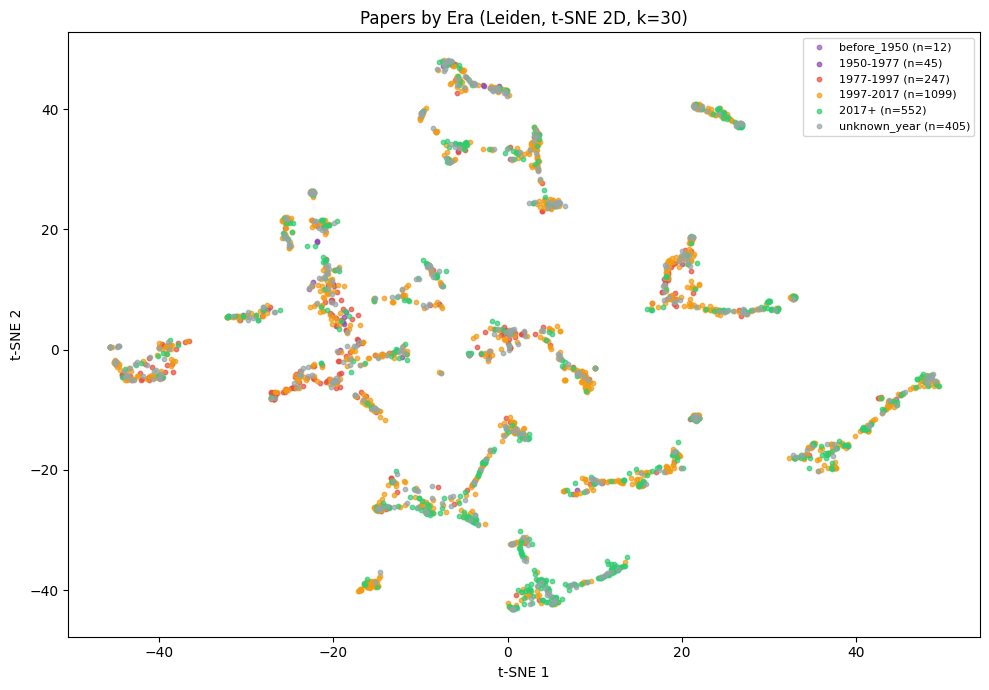

Saved: /home/john/repos/leno4ka/output/graph/rq3_leiden_era_tsne2d.png


In [ ]:
# ============================================================
# t-SNE 2D visualization for cluster-based methods
# Reads cluster labels from paper_clusters.csv (k is dynamic)
# ============================================================

# Guard: load paper_50d if kernel restarted
try:
    paper_matrix_norm
    paper_filenames
except NameError:
    _p50 = np.load(GRAPH_DIR / "paper_50d.npy")
    _cl  = pd.read_csv(GRAPH_DIR / "paper_clusters.csv")
    paper_filenames = _cl["filename"].tolist()
    paper_matrix_norm = _p50   # t-SNE runs on 50d space too for consistency

# Staleness check: warn if paper_clusters.csv was saved with a different k than best_k
_k_csv_path = GRAPH_DIR / "k_selection_metrics.csv"
if os.path.exists(_k_csv_path):
    _k_df = pd.read_csv(_k_csv_path)
    if "composite" not in _k_df.columns:
        print("WARNING: k_selection_metrics.csv has no 'composite' column — re-run cell 15 to regenerate it.")
    else:
        _best_k = int(_k_df.loc[_k_df["composite"].idxmax(), "k"])
        _saved_k = pd.read_csv(GRAPH_DIR / "paper_clusters.csv")["cluster"].nunique()
        if _saved_k != _best_k:
            print(f"WARNING: paper_clusters.csv has k={_saved_k} but best_k={_best_k}.")
            print("Re-run cell 20 to regenerate paper_clusters.csv with the correct k.")
        else:
            print(f"paper_clusters.csv is up to date (k={_saved_k})")

print("Running t-SNE (2D)...")
tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,
    metric="cosine",
    random_state=42,
    init="pca",
    learning_rate="auto",
)
paper_tsne = tsne.fit_transform(paper_matrix_norm)

tsne_coords_df = pd.DataFrame({
    "filename": paper_filenames,
    "tsne1": paper_tsne[:, 0],
    "tsne2": paper_tsne[:, 1],
})
tsne_coords_df.to_csv(GRAPH_DIR / "paper_tsne2d_coords.csv", index=False)
print("t-SNE coords saved.")

# Read era info
_meta = pd.read_csv(OUTPUT_DIR / "metadata_enriched_after_openalex_year.csv")
_meta["filename"] = _meta["pdf_file"].str.replace(".pdf", "", regex=False)
try:
    era_df_tsne = _meta[["filename", "era"]].copy()
except KeyError:
    def _get_era(y):
        """Execute _get_era."""
        if pd.isna(y): 
            return "unknown_year"
        y = int(y)
        if y < 1950:  
            return "before_1950"
        if y < 1977:  
            return "1950-1977"
        if y < 1997:  
            return "1977-1997"
        if y < 2017:  
            return "1997-2017"
        return "2017+"
    _meta["_year_combined"] = _meta["crossref_year"].combine_first(_meta["original_year"]).combine_first(_meta.get("openalex_year", pd.Series(dtype=float)))
_meta["era"] = _meta["_year_combined"].apply(_get_era)
era_df_tsne = _meta[["filename", "era"]].copy()
era_df_tsne["era"] = era_df_tsne["era"].fillna("unknown_year")

kmeans_df_t = pd.read_csv(GRAPH_DIR / "paper_clusters.csv")
leiden_df_t = pd.read_csv(GRAPH_DIR / "paper_clusters_leiden.csv")
_k_used = kmeans_df_t["cluster"].nunique()
_leiden_k = leiden_df_t["leiden_cluster"].nunique()
print(f"KMeans k={_k_used} | Leiden communities={_leiden_k} (emergent, not controlled by best_k)")

plot_jobs_tsne = [
    ("kmeans", kmeans_df_t, "cluster"),
    ("leiden", leiden_df_t, "leiden_cluster"),
]

era_order = ["before_1950", "1950-1977", "1977-1997", "1997-2017", "2017+", "unknown_year"]
era_colors = {
    "before_1950": "#9b59b6", "1950-1977": "#8e44ad", "1977-1997": "#e74c3c",
    "1997-2017": "#f39c12",   "2017+": "#2ecc71",     "unknown_year": "#95a5a6",
}

for method_name, labels_df, cluster_col in plot_jobs_tsne:
    plot_df = tsne_coords_df.merge(labels_df[["filename", cluster_col]], on="filename", how="inner")
    plot_df = plot_df.merge(era_df_tsne, on="filename", how="left")
    plot_df["era"] = plot_df["era"].fillna("unknown_year")

    unique_clusters = sorted(pd.unique(plot_df[cluster_col]))
    n_clusters = len(unique_clusters)
    cmap = plt.cm.get_cmap("tab20", max(1, n_clusters))

    # --- by cluster ---
    fig, ax = plt.subplots(figsize=(10, 7))
    for idx, c in enumerate(unique_clusters):
        mask = plot_df[cluster_col] == c
        ax.scatter(plot_df.loc[mask, "tsne1"], plot_df.loc[mask, "tsne2"],
                   color=cmap(idx), s=10, alpha=0.7, label=f"C{c} (n={mask.sum()})")
    ax.set_title(f"Papers by {method_name.capitalize()} Clusters — t-SNE 2D  (k={n_clusters})")
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=7, ncols=2)
    plt.tight_layout()
    out = GRAPH_DIR + f"rq3_{method_name}_clusters_tsne2d.png"
    plt.savefig(out, dpi=150); plt.show()
    print(f"Saved: {out}")

    # --- by era ---
    fig, ax = plt.subplots(figsize=(10, 7))
    for era in era_order:
        mask = plot_df["era"] == era
        if mask.sum() == 0: continue
        ax.scatter(plot_df.loc[mask, "tsne1"], plot_df.loc[mask, "tsne2"],
                   c=era_colors[era], s=10, alpha=0.7, label=f"{era} (n={mask.sum()})")
    ax.set_title(f"Papers by Era ({method_name.capitalize()}, t-SNE 2D, k={n_clusters})")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=8)
    plt.tight_layout()
    out = GRAPH_DIR + f"rq3_{method_name}_era_tsne2d.png"
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"Saved: {out}")


Run t-SNE 2-D on the 50-D paper embeddings and produce side-by-side scatter plots coloured by KMeans/Leiden clusters and by historical era.

In [51]:
try:
    _ = metrics_df
except NameError:
    metrics_df = pd.read_csv(GRAPH_DIR / "graph_metrics_full.csv")
try:
    _ = cluster_df
except NameError:
    cluster_df = pd.read_csv(GRAPH_DIR / "paper_clusters.csv")

G = nx.read_gexf(OUTPUT_DIR / "graph/graph_full.gexf")

def case_study(filename, G, metrics_df, cluster_df):
    """Execute case_study."""
    row = metrics_df[metrics_df["node"] == filename].iloc[0]
    cluster_row = cluster_df[cluster_df["filename"] == filename].iloc[0]

    print(f"{filename}")
    print(f"Era: {row['era']} | Cluster: {cluster_row['cluster']}")
    print(f"Degree: {row['degree']} | PageRank: {row['pagerank']:.6f} | Betweenness: {row['betweenness']:.6f}")

    neighbors = list(G.neighbors(filename))
    authors = [n for n in neighbors if G.nodes[n].get("type") == "Author" and "nan" not in n.lower()]
    keywords = [n for n in neighbors if G.nodes[n].get("type") == "Keyword"]

    print(f"Authors: {authors[:5]}")
    print(f"Top keywords: {keywords[:10]}")
    print()

for paper in ["01Hirsch", "06Leonard b", "00Cowan"]:
    case_study(paper, G, metrics_df, cluster_df)


01Hirsch
Era: 1997-2017 | Cluster: 0
Degree: 204 | PageRank: 0.001370 | Betweenness: 0.032561
Authors: []
Top keywords: ['art', 'humanity', 'development', 'education', 'play', 'chess philosophy', 'chess symbolism', 'chess aesthetics', 'chess basics', 'chess life']

06Leonard b
Era: 2017+ | Cluster: 10
Degree: 288 | PageRank: 0.001776 | Betweenness: 0.043485
Authors: ['Clare Aspray', 'Fiona Aspray', 'Kate Aspray', 'Patrick Aspray', 'Terence Aspray']
Top keywords: ['psychological variable', 'selfishness', 'principles', 'ethics', 'resentment', 'minimax theorem', 'von neumann', 'strategic interaction', 'john von neumann', 'assimilation']

00Cowan
Era: 1997-2017 | Cluster: 5
Degree: 302 | PageRank: 0.002360 | Betweenness: 0.015173
Authors: ['Nelson Cowan']
Top keywords: ['capacity limit', 'information overload', 'rehearsal', 'sensory memory', 'storage capacity', 'cognitive psychology', 'memory decay', 'memory capacity', 'compound stm estimates', 'serial order']



---------------
Comparison of graph-based and cluster-based approaches for RQ3
--------------------------------------------

In [ ]:
# ============================================================
# RQ3: COMPARISON — SKG (graph) vs Clustering (KMeans/Leiden)
# ============================================================

# Paths
# Load data
meta = pd.read_csv(OUTPUT_DIR / "metadata_enriched_after_openalex_year.csv")
meta["filename"] = meta["pdf_file"].str.replace(".pdf", "", regex=False)

def get_era(year):
    """Execute get_era."""
    if pd.isna(year):
        return "unknown_year"
    year = int(year)
    if 1950 <= year < 1977: return "1950-1977"
    if 1977 <= year < 1997: return "1977-1997"
    if 1997 <= year < 2017: return "1997-2017"
    if year >= 2017:        return "2017+"
    return "before_1950"

meta["_year_combined"] = meta["crossref_year"].combine_first(meta["original_year"]).combine_first(meta.get("openalex_year", pd.Series(dtype=float)))
meta["era"] = meta["_year_combined"].apply(get_era)


graph_metrics  = pd.read_csv(GRAPH_DIR / "graph_metrics_full.csv")
kmeans_df      = pd.read_csv(GRAPH_DIR / "paper_clusters.csv")
leiden_df      = pd.read_csv(GRAPH_DIR / "paper_clusters_leiden.csv")
leiden_labels  = pd.read_csv(GRAPH_DIR / "leiden_cluster_labels.csv")

print("graph_metrics columns:", graph_metrics.columns.tolist())
print("kmeans_df columns:    ", kmeans_df.columns.tolist())
print("leiden_df columns:    ", leiden_df.columns.tolist())
print("meta columns:         ", meta.columns.tolist())

# Merge everything into one paper-level DataFrame
papers = graph_metrics[graph_metrics["type"] == "Paper"].copy()
papers = papers.merge(meta[["filename", "crossref_year", "era",
                             "crossref_authors", "original_authors",
                             "original_title"]], 
                      left_on="node", right_on="filename", how="left")
papers = papers.merge(kmeans_df, left_on="node", right_on="filename", how="left")
papers = papers.merge(leiden_df, left_on="node", right_on="filename", how="left")

G = nx.read_gexf(GRAPH_DIR / "graph_full.gexf")

print(f"Papers in combined df: {len(papers)}")
print(papers[["node", "degree", "pagerank", "betweenness", "cluster", "leiden_cluster"]].head(3))

graph_metrics columns: ['node', 'type', 'era', 'year', 'degree', 'pagerank', 'betweenness']
kmeans_df columns:     ['filename', 'cluster']
leiden_df columns:     ['filename', 'leiden_cluster']
meta columns:          ['pdf_file', 'original_title', 'original_authors', 'original_year', 'enriched', 'doi', 'crossref_title', 'crossref_authors', 'crossref_year', 'title_similarity', 'crossref_references', 'crossref_subject', 'crossref_journal', 'crossref_publisher', 'crossref_type', 'crossref_abstract', 'crossref_issn', 'crossref_volume', 'crossref_issue', 'crossref_page', 'crossref_event_name', 'crossref_language', 'openalex_work_id', 'openalex_matched_title', 'openalex_match_similarity', 'filename', 'era']
Papers in combined df: 2376
                              node  degree  pagerank  betweenness  cluster  \
0  00AlissandrakisNehanivDeutenhan      31  0.000211     0.000817      8.0   
1            00BaenaBelmonteMandow      30  0.000249     0.001103      8.0   
2                         00

Merge graph metrics, metadata, KMeans, and Leiden assignments into one paper-level DataFrame; load the full GEXF graph.

In [ ]:
# ============================================================
# DIMENSION 1: Cross-cluster authors (only visible via graph)
# ============================================================

# For each author node in G, find which KMeans clusters their papers fall into
author_cluster_info = []

for node, data in G.nodes(data=True):
    if data.get("type") != "Author":
        continue
    if "nan" in node.lower():
        continue
    # papers connected to this author
    neighbor_papers = [n for n in G.neighbors(node) 
                       if G.nodes[n].get("type") == "Paper"]
    if len(neighbor_papers) < 2:
        continue
    
    paper_df = papers[papers["node"].isin(neighbor_papers)][["node", "cluster", "leiden_cluster"]]
    kmeans_clusters = paper_df["cluster"].dropna().unique()
    leiden_clusters = paper_df["leiden_cluster"].dropna().unique()
    
    if len(kmeans_clusters) > 1:
        author_cluster_info.append({
            "author": node,
            "n_papers": len(neighbor_papers),
            "kmeans_clusters": sorted(kmeans_clusters.tolist()),
            "n_kmeans_clusters": len(kmeans_clusters),
            "leiden_clusters": sorted(leiden_clusters.tolist()),
            "n_leiden_clusters": len(leiden_clusters),
        })

cross_df = pd.DataFrame(author_cluster_info).sort_values(
    ["n_kmeans_clusters", "n_papers"], ascending=False
)

print(f"\nAuthors spanning >1 KMeans cluster: {len(cross_df)}")
print("\nTop 15 cross-cluster authors (KMeans):")
print(cross_df[["author", "n_papers", "n_kmeans_clusters", "n_leiden_clusters"]].head(15).to_string(index=False))

cross_df.to_csv(GRAPH_DIR / "rq3_cross_cluster_authors.csv", index=False)
print("\nSaved: rq3_cross_cluster_authors.csv")


Authors spanning >1 KMeans cluster: 178

Top 15 cross-cluster authors (KMeans):
              author  n_papers  n_kmeans_clusters  n_leiden_clusters
          Matej Guid        17                  7                  9
  Jonathan Schaeffer        19                  5                  7
       Merim Bilalić        19                  5                  7
    Paolo Ciancarini        17                  5                  8
         Ivan Bratko        16                  5                  6
       Neil Charness        15                  5                  4
Guillermo Campitelli        15                  5                  5
      Tsan-sheng Hsu         8                  5                  5
         Mark Levene         6                  5                  5
      G.McC. Haworth         9                  4                  4
 Nathan S. Netanyahu         9                  4                  4
       Hiroyuki Iida         7                  4                  6
       Jr-Chang Chen  

Identify authors whose papers span multiple KMeans clusters (cross-domain author mobility — a graph-exclusive signal).

In [ ]:
# ============================================================
# DIMENSION 2: Bridge keywords — spanning multiple clusters
# ============================================================

bridge_rows = []

for node, data in G.nodes(data=True):
    if data.get("type") != "Keyword":
        continue
    neighbor_papers = [n for n in G.neighbors(node)
                       if G.nodes[n].get("type") == "Paper"]
    if len(neighbor_papers) < 3:
        continue
    
    paper_df = papers[papers["node"].isin(neighbor_papers)][["node", "cluster", "leiden_cluster"]]
    kmeans_clusters = paper_df["cluster"].dropna().unique()
    leiden_clusters = paper_df["leiden_cluster"].dropna().unique()
    
    # Cluster entropy: how evenly is keyword distributed across clusters?
    cluster_counts = paper_df["cluster"].dropna().value_counts(normalize=True)
    kw_entropy = entropy(cluster_counts)
    
    bridge_rows.append({
        "keyword": node,
        "n_papers": len(neighbor_papers),
        "n_kmeans_clusters": len(kmeans_clusters),
        "n_leiden_clusters": len(leiden_clusters),
        "cluster_entropy": round(kw_entropy, 4),
    })

bridge_df = pd.DataFrame(bridge_rows).sort_values(
    ["n_kmeans_clusters", "cluster_entropy"], ascending=False
)

print("Bridge keywords (≥3 papers, spanning all 4 KMeans clusters):")
top_bridge = bridge_df[bridge_df["n_kmeans_clusters"] == 4].sort_values("n_papers", ascending=False)
print(top_bridge.head(20).to_string(index=False))

bridge_df.to_csv(GRAPH_DIR / "rq3_bridge_keywords.csv", index=False)
print("\nSaved: rq3_bridge_keywords.csv")

Bridge keywords (≥3 papers, spanning all 4 KMeans clusters):
               keyword  n_papers  n_kmeans_clusters  n_leiden_clusters  cluster_entropy
      fitness function        32                  4                  6           0.5819
    gender differences        30                  4                  5           0.4349
               speedup        29                  4                  4           0.4462
                mtd(f)        29                  4                  6           1.2583
     production system        28                  4                  6           0.9255
     chess instruction        27                  4                  6           0.9204
  general game playing        27                  4                  7           0.9853
           policy head        26                  4                  5           0.6924
            value head        25                  4                  5           0.7593
       computer vision        25                  4        

Find bridge keywords that appear across many clusters, measuring their cluster-entropy as a proxy for conceptual breadth.

In [ ]:
# ============================================================
# DIMENSION 3: Temporal diversity per cluster
# ============================================================

ERA_ORDER = ["1950-1977", "1977-1997", "1997-2017", "2017+", "unknown_year"]


def temporal_diversity(cluster_col, df):
    """Execute temporal_diversity."""
    rows = []
    for cid in sorted(df[cluster_col].dropna().unique()):
        subset = df[df[cluster_col] == cid]
        
        n_unknown = (subset["era_x"] == "unknown_year").sum()
        pct_unknown = round(n_unknown / len(subset) * 100, 1)
        
        known = subset[subset["era_x"] != "unknown_year"]["era_x"]
        era_dist_known = known.value_counts(normalize=True)
        
        if len(era_dist_known) > 0:
            dominant_era = era_dist_known.idxmax()
            dom_share = round(era_dist_known.max(), 3)
            n_significant_eras = int((era_dist_known > 0.05).sum())
            era_entropy = round(entropy(era_dist_known), 4)
        else:
            dominant_era = "N/A"
            dom_share = 0.0
            n_significant_eras = 0
            era_entropy = 0.0
        
        rows.append({
            "cluster": cid,
            "size": len(subset),
            "n_unknown_year": int(n_unknown),
            "pct_unknown_year": pct_unknown,
            "n_significant_eras": n_significant_eras,
            "dominant_era": dominant_era,
            "dominant_era_share": dom_share,
            "era_entropy": era_entropy,
        })
    return pd.DataFrame(rows)

kmeans_temporal = temporal_diversity("cluster", papers)
leiden_temporal = temporal_diversity("leiden_cluster", papers)

print(f"=== KMeans k={papers['cluster'].nunique()}: temporal diversity ===")
print(kmeans_temporal.to_string(index=False))
print()
print(f"=== Leiden ({leiden_df['leiden_cluster'].nunique()} clusters): temporal diversity summary ===")
print(f"Clusters spanning ≥2 eras: {(leiden_temporal['n_significant_eras'] >= 2).sum()} / {len(leiden_temporal)}")
print(f"Avg era entropy — KMeans: {kmeans_temporal['era_entropy'].mean():.3f} | Leiden: {leiden_temporal['era_entropy'].mean():.3f}")

kmeans_temporal.to_csv(GRAPH_DIR / "rq3_kmeans_temporal.csv", index=False)
leiden_temporal.to_csv(GRAPH_DIR / "rq3_leiden_temporal.csv", index=False)
print("\nSaved: rq3_kmeans_temporal.csv, rq3_leiden_temporal.csv")

=== KMeans k=13: temporal diversity ===
 cluster  size  n_unknown_year  pct_unknown_year  n_significant_eras dominant_era  dominant_era_share  era_entropy
     0.0   254              84              33.1                   3    1997-2017               0.571       1.1009
     1.0   277             111              40.1                   3    1997-2017               0.530       1.1245
     2.0   131              34              26.0                   3    1997-2017               0.588       0.9264
     3.0   219              95              43.4                   2    1997-2017               0.621       0.8569
     4.0    79              27              34.2                   2    1997-2017               0.615       0.7426
     5.0   192              49              25.5                   3    1997-2017               0.678       0.8977
     6.0   120              20              16.7                   2    1997-2017               0.630       0.7857
     7.0   182              83          

Compute temporal diversity (era entropy, dominant era, unknown-year rate) for every KMeans and Leiden cluster.

In [ ]:
# ============================================================
# DIMENSION 4: Structural summary — what each method reveals
# ============================================================

# Top-10 papers by betweenness (graph-structural importance)
papers_named = papers[
    papers["original_title"].notna() &
    (~papers["original_title"].astype(str).str.strip().isin(["nan", "NaN", "", "None"])) &
    papers["crossref_year"].notna()
]
top_betweenness = papers_named.nlargest(10, "betweenness")[
    ["node", "original_title", "crossref_year", "era_x",
     "betweenness", "pagerank", "cluster", "leiden_cluster"]
]

print("Top-10 papers by Betweenness Centrality (graph view):")
print(top_betweenness[["original_title", "crossref_year", "cluster",
                        "leiden_cluster", "betweenness"]].to_string(index=False))
top_betweenness.to_csv(GRAPH_DIR / "rq3_top_betweenness_papers.csv", index=False)

print()
cluster_spread = top_betweenness["cluster"].value_counts()
print(f"KMeans cluster distribution of top-10 betweenness papers:\n{cluster_spread.to_string()}")
print()

# Comparison summary
summary = {
    "Dimension": [
        "Number of groups/communities",
        "Cross-domain author detection",
        "Bridge keyword identification",
        "Temporal coverage per group",
        "Paper influence ranking",
        "Author collaboration network",
        "Requires embedding model",
        "Interpretability",
    ],
    "SKG (Graph)": [
        f"Leiden: {leiden_df['leiden_cluster'].nunique()} communities (emergent)",
        f"✓ {len(cross_df)} cross-cluster authors identified",
        "✓ Bridge keywords via centrality",
        "✓ Per paper, not averaged",
        "✓ PageRank / Betweenness",
        "✓ Explicit co-authorship edges",
        "✗ No (uses graph topology)",
        "Structural (network metrics)",
    ],
    "Clustering (KMeans/Leiden-emb)": [
        f"KMeans: k={papers['cluster'].nunique()} (composite-optimal); Leiden-emb: {leiden_df['leiden_cluster'].nunique()} (emergent)",
        "✗ Not directly visible",
        "✗ Not directly visible",
        "Averaged within cluster",
        "✗ No centrality notion",
        "✗ Not modeled",
        "✓ Yes (Qwen3 embeddings)",
        "Semantic (topic similarity)",
    ],
}

summary_df = pd.DataFrame(summary)
print("\n=== COMPARATIVE SUMMARY ===")
print(summary_df.to_string(index=False))
summary_df.to_csv(GRAPH_DIR / "rq3_comparison_summary.csv", index=False)
print("\nSaved: rq3_comparison_summary.csv")

Top-10 papers by Betweenness Centrality (graph view):
                                                                             original_title  crossref_year  cluster  leiden_cluster  betweenness
    The magical number 4 in short-term memory: A reconsideration of mental storage capacity         2001.0      5.0             1.0     0.015173
      Automatic detection of users’ skill levels using high-frequency user interface events         2010.0      5.0             1.0     0.014709
       Is chess the drosophila of artificial intelligence? A social history of an algorithm         2012.0      1.0            24.0     0.009837
                                               The architecture of the chess player׳s brain         2014.0      5.0            29.0     0.008708
                 Monte Carlo Tree Search: a review of recent modifications and applications         2023.0      3.0             6.0     0.007779
                                                                        Lego

---
## RQ2: Comparative Analysis — Graph vs. Clustering for Cross-Era Transitional Research

Measurable indicators:
1. **HDBSCAN noise papers** — papers that don't firmly belong to any semantic cluster (cluster-side transitional)
2. **KMeans distance-to-centroid** — papers far from their cluster centroid (cluster-side transitional, alternative)
3. **Graph betweenness** — papers bridging many shortest paths in the SKG (graph-side transitional)
4. **ARI (Adjusted Rand Index)** — how well each clustering aligns with historical eras
5. **Set overlap (Jaccard)** — agreement between graph and cluster methods on which papers are transitional
6. **Era distribution** — which eras each method uniquely flags as transitional


In [ ]:
try:
    paper_50d
    paper_filenames
    cluster_labels
    kmeans
except NameError:
    print("Loading paper_50d, cluster_labels, kmeans_centroids from disk...")
    paper_50d = np.load(GRAPH_DIR / "paper_50d.npy")
    _cl = pd.read_csv(GRAPH_DIR / "paper_clusters.csv")
    paper_filenames = _cl["filename"].tolist()
    cluster_labels  = _cl["cluster"].values
    # Reconstruct KMeans object with saved centroids so .cluster_centers_ is available
    _centroids = np.load(GRAPH_DIR / "kmeans_centroids.npy")
    kmeans = KMeans(n_clusters=_centroids.shape[0], random_state=42, n_init=10)
    kmeans.cluster_centers_ = _centroids
    print(f"Loaded: paper_50d {paper_50d.shape}, {len(paper_filenames)} papers")

try:
    GRAPH_DIR
except NameError:
    GRAPH_DIR = GRAPH_DIR

# ============================================================
# INDICATOR 1 & 2: Cluster-based transitional paper detection
# — HDBSCAN (noise points) + KMeans distance-to-centroid
# Requires paper_50d, kmeans, cluster_labels, paper_filenames
# from the UMAP/KMeans cells above.
# ============================================================

# --- Method A: HDBSCAN — noise papers have no firm cluster home ---
hdb = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5, metric="euclidean")
hdb_labels = hdb.fit_predict(paper_50d)

n_hdb_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = (hdb_labels == -1).sum()
print(f"HDBSCAN: {n_hdb_clusters} clusters, {n_noise} noise papers ({n_noise / len(hdb_labels) * 100:.1f}%)")

non_noise = hdb_labels != -1
if non_noise.sum() > 1:
    sil = silhouette_score(paper_50d[non_noise], hdb_labels[non_noise])
    print(f"Silhouette (non-noise): {sil:.4f}")

hdbscan_df = pd.DataFrame({
    "filename": paper_filenames,
    "hdbscan_cluster": hdb_labels,
    "hdbscan_outlier_score": hdb.outlier_scores_,
})
hdbscan_df.to_csv(GRAPH_DIR / "rq2_paper_clusters_hdbscan.csv", index=False)
print("Saved: rq2_paper_clusters_hdbscan.csv")

# --- Method B: KMeans distance-to-centroid ---
centroids = kmeans.cluster_centers_
dist_to_centroid = np.linalg.norm(paper_50d - centroids[cluster_labels], axis=1)

# Top 15% farthest from centroid = "boundary" papers
centroid_threshold = np.quantile(dist_to_centroid, 0.85)
print(f"\nKMeans distance-to-centroid threshold (top 15%): {centroid_threshold:.4f}")

centroid_df_rq2 = pd.DataFrame({
    "filename": paper_filenames,
    "cluster": cluster_labels,
    "dist_to_centroid": dist_to_centroid,
    "is_boundary": dist_to_centroid >= centroid_threshold,
})
centroid_df_rq2.to_csv(GRAPH_DIR / "rq2_centroid_distances.csv", index=False)
print(f"Boundary papers (top 15% dist): {centroid_df_rq2['is_boundary'].sum()}")
print("Saved: rq2_centroid_distances.csv")

HDBSCAN: 39 clusters, 662 noise papers (28.1%)
Silhouette (non-noise): 0.5162
Saved: rq2_paper_clusters_hdbscan.csv

KMeans distance-to-centroid threshold (top 15%): 0.9291
Boundary papers (top 15% dist): 354
Saved: rq2_centroid_distances.csv


Run HDBSCAN on the 50-D embedding space to identify noise/outlier papers, and compute KMeans distance-to-centroid for all papers.

In [ ]:
# ============================================================
# INDICATOR 3 & 4: Graph-based transitional papers + ARI for all methods
# ============================================================

ERA_TO_INT = {
    "before_1950": 0, "1950-1977": 1, "1977-1997": 2,
    "1997-2017": 3, "2017+": 4, "unknown_year": 5,
}

# Graph-based transitional papers: top 15% by betweenness (match cluster 15% threshold)
btw_threshold = papers["betweenness"].quantile(0.85)
papers["is_transitional_graph"] = papers["betweenness"] >= btw_threshold
print(f"Graph betweenness threshold (top 15%): {btw_threshold:.6f}")
print(f"Graph-transitional papers: {papers['is_transitional_graph'].sum()}")

# ARI: how well does each clustering align with historical eras?
papers_ari = papers.dropna(subset=["era_x", "cluster", "leiden_cluster"]).copy()
papers_ari["era_int"] = papers_ari["era_x"].map(ERA_TO_INT)
papers_ari = papers_ari.dropna(subset=["era_int"])

ari_kmeans = adjusted_rand_score(
    papers_ari["era_int"].astype(int),
    papers_ari["cluster"].astype(int),
)
ari_leiden = adjusted_rand_score(
    papers_ari["era_int"].astype(int),
    papers_ari["leiden_cluster"].astype(int),
)

# ARI for HDBSCAN — select only needed columns first to avoid the duplicate
# filename column error (papers already has filename_x, filename_y, filename
# from the three prior merges in cell c72b1b52).
hdbscan_merge = papers_ari[["node", "era_int"]].merge(
    hdbscan_df[["filename", "hdbscan_cluster"]],
    left_on="node", right_on="filename", how="inner"
)
hdbscan_known = hdbscan_merge[hdbscan_merge["hdbscan_cluster"] != -1]
ari_hdbscan = adjusted_rand_score(
    hdbscan_known["era_int"].astype(int),
    hdbscan_known["hdbscan_cluster"].astype(int),
) if len(hdbscan_known) > 1 else float("nan")

print("\n=== ARI vs Historical Era (higher = better temporal alignment) ===")
print(f"KMeans  (k={papers_ari['cluster'].nunique()}):                    {ari_kmeans:.4f}")
print(f"Leiden  (embedding kNN, 31 groups): {ari_leiden:.4f}")
print(f"HDBSCAN (non-noise only):           {ari_hdbscan:.4f}")
print("Interpretation: 0 = random, 1 = perfect, >0.1 = meaningful alignment")


Graph betweenness threshold (top 15%): 0.001860
Graph-transitional papers: 357

=== ARI vs Historical Era (higher = better temporal alignment) ===
KMeans  (k=13):                    0.0102
Leiden  (embedding kNN, 31 groups): 0.0094
HDBSCAN (non-noise only):           0.0114
Interpretation: 0 = random, 1 = perfect, >0.1 = meaningful alignment


Compute ARI against historical eras for KMeans, Leiden, and HDBSCAN, establishing how well each method captures temporal structure.

In [ ]:
# ============================================================
# INDICATOR 5: Set-level comparison — which papers does each
# method flag as "transitional"? Jaccard + unique discoveries
# ============================================================

graph_set      = set(papers[papers["is_transitional_graph"]]["node"].tolist())
hdbscan_set    = set(hdbscan_df[hdbscan_df["hdbscan_cluster"] == -1]["filename"].tolist())
centroid_set   = set(centroid_df_rq2[centroid_df_rq2["is_boundary"]]["filename"].tolist())

def jaccard(a, b):
    """Execute jaccard."""
    return len(a & b) / len(a | b) if (a | b) else 0.0

print("=== Transitional Paper Sets ===")
print(f"Graph (betweenness top 15%):          {len(graph_set):4d} papers")
print(f"Cluster-HDBSCAN (noise points):       {len(hdbscan_set):4d} papers")
print(f"Cluster-KMeans boundary (top 15%):    {len(centroid_set):4d} papers")

print("\n=== Pairwise Jaccard Similarity ===")
print(f"Graph ∩ HDBSCAN:             {len(graph_set & hdbscan_set):3d} shared  (Jaccard: {jaccard(graph_set, hdbscan_set):.3f})")
print(f"Graph ∩ KMeans-boundary:     {len(graph_set & centroid_set):3d} shared  (Jaccard: {jaccard(graph_set, centroid_set):.3f})")
print(f"HDBSCAN ∩ KMeans-boundary:   {len(hdbscan_set & centroid_set):3d} shared  (Jaccard: {jaccard(hdbscan_set, centroid_set):.3f})")

all_three = graph_set & hdbscan_set & centroid_set
graph_only = graph_set - hdbscan_set - centroid_set
cluster_only = (hdbscan_set | centroid_set) - graph_set

print(f"\nAll three methods agree:             {len(all_three):3d} papers")
print(f"Graph-only (invisible to clustering):{len(graph_only):3d} papers")
print(f"Cluster-only (invisible to graph):   {len(cluster_only):3d} papers")

# Era breakdown: do the methods flag different historical periods?
era_lookup = papers.set_index("node")["era_x"].to_dict()

def era_dist(paper_set):
    """Execute era_dist."""
    eras = [era_lookup.get(p, "unknown_year") for p in paper_set]
    return pd.Series(eras).value_counts()

print("\n=== Era Distribution of Transitional Papers (excl. unknown_year) ===")
era_compare = pd.DataFrame({
    "Graph": era_dist(graph_set),
    "HDBSCAN": era_dist(hdbscan_set),
    "KMeans-boundary": era_dist(centroid_set),
    "All-three": era_dist(all_three),
    "Graph-only": era_dist(graph_only),
}).fillna(0).astype(int)

era_order_display = ["1950-1977", "1977-1997", "1997-2017", "2017+", "before_1950", "unknown_year"]
era_compare = era_compare.reindex([e for e in era_order_display if e in era_compare.index])
print(era_compare.to_string())

# Save
era_compare.to_csv(GRAPH_DIR / "rq2_transitional_era_comparison.csv")
overlap_df = pd.DataFrame({
    "filename": list(all_three),
    "era": [era_lookup.get(p, "unknown_year") for p in all_three],
    "betweenness": [papers[papers["node"] == p]["betweenness"].values[0]
                    if p in papers["node"].values else None for p in all_three],
})
overlap_df.to_csv(GRAPH_DIR / "rq2_consensus_transitional_papers.csv", index=False)
print("\nSaved: rq2_transitional_era_comparison.csv, rq2_consensus_transitional_papers.csv")


=== Transitional Paper Sets ===
Graph (betweenness top 15%):           357 papers
Cluster-HDBSCAN (noise points):        662 papers
Cluster-KMeans boundary (top 15%):     354 papers

=== Pairwise Jaccard Similarity ===
Graph ∩ HDBSCAN:             102 shared  (Jaccard: 0.111)
Graph ∩ KMeans-boundary:      56 shared  (Jaccard: 0.085)
HDBSCAN ∩ KMeans-boundary:   153 shared  (Jaccard: 0.177)

All three methods agree:              25 papers
Graph-only (invisible to clustering):224 papers
Cluster-only (invisible to graph):   730 papers

=== Era Distribution of Transitional Papers (excl. unknown_year) ===
              Graph  HDBSCAN  KMeans-boundary  All-three  Graph-only
1950-1977         4       15                0          0           3
1977-1997        27       61               32          3          14
1997-2017       170      226              121         15         107
2017+            69      122               75          4          47
before_1950       1        3                0  

Compute pairwise Jaccard similarity between graph-, HDBSCAN-, and KMeans-identified transitional paper sets and break down by historical era.

=== RQ2 Final Comparative Indicators ===
                        Indicator Graph (betweenness) Cluster-HDBSCAN (noise) Cluster-KMeans (boundary)
    # transitional papers flagged                 357                     662                       354
# papers flagged by all 3 methods                  25                      25                        25
     # unique to this method only                 224                     432                       170
                 Jaccard vs Graph                 1.0                   0.111                     0.085
            ARI vs historical era                 N/A                  0.0114                    0.0102
        Avg era entropy per group           per-paper     N/A (noise=outlier)                     0.971
         Requires embedding model                  No                     Yes                       Yes
     Detects cross-author bridges   Yes (108 authors)                      No                        No

Saved: rq2_final_indic

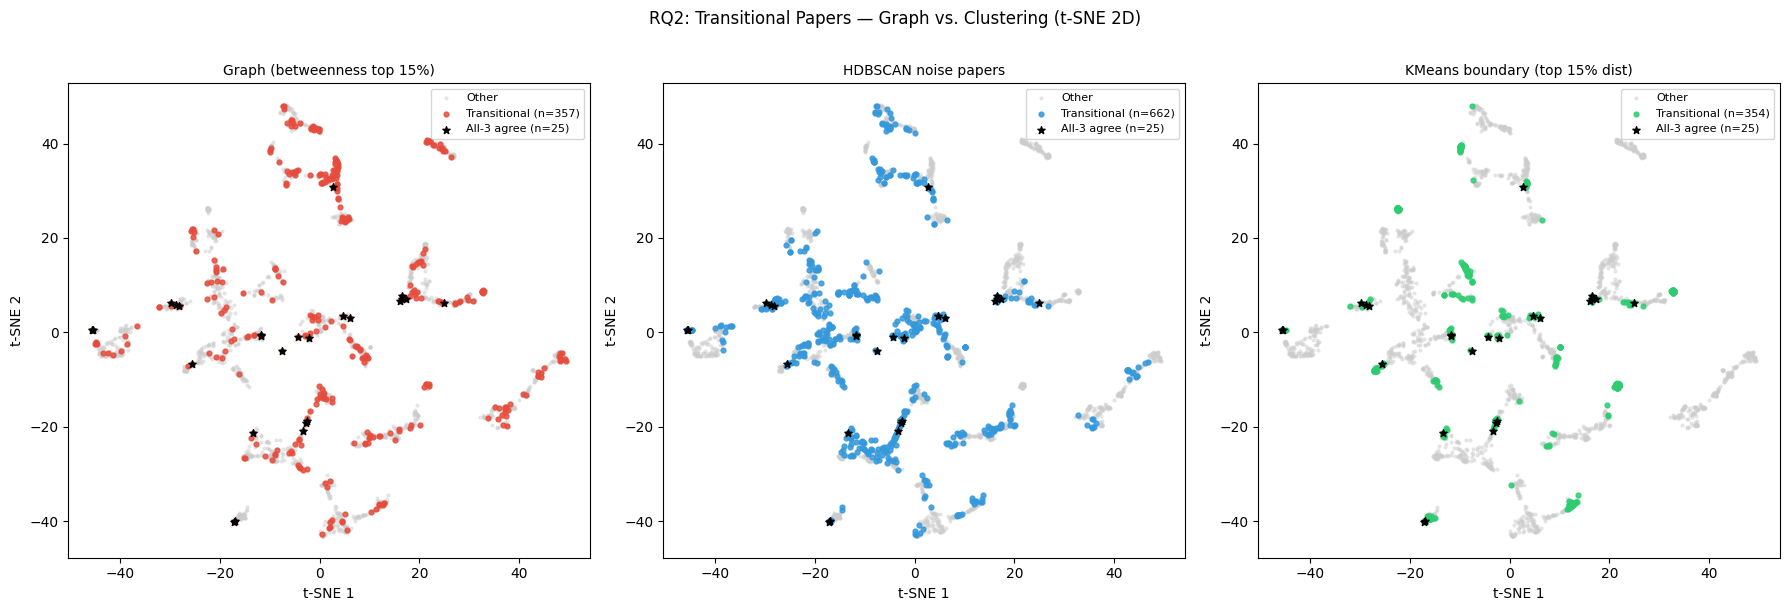

Saved: rq2_transitional_comparison_tsne.png


In [ ]:
# ============================================================
# INDICATOR 6: Final measurable indicators table + UMAP plot
# showing consensus transitional papers highlighted
# ============================================================

# --- Summary table ---
summary_rows = [
    ("# transitional papers flagged",
     len(graph_set), len(hdbscan_set), len(centroid_set)),
    ("# papers flagged by all 3 methods",
     len(all_three), len(all_three), len(all_three)),
    ("# unique to this method only",
     len(graph_only),
     len(hdbscan_set - graph_set - centroid_set),
     len(centroid_set - graph_set - hdbscan_set)),
    ("Jaccard vs Graph",
     1.0, round(jaccard(graph_set, hdbscan_set), 3), round(jaccard(graph_set, centroid_set), 3)),
    ("ARI vs historical era",
     "N/A", round(ari_hdbscan, 4), round(ari_kmeans, 4)),
    ("Avg era entropy per group",
     "per-paper", "N/A (noise=outlier)", round(kmeans_temporal["era_entropy"].mean(), 3)),
    ("Requires embedding model", "No", "Yes", "Yes"),
    ("Detects cross-author bridges", "Yes (108 authors)", "No", "No"),
]

summary_df_rq2 = pd.DataFrame(
    summary_rows,
    columns=["Indicator", "Graph (betweenness)", "Cluster-HDBSCAN (noise)", "Cluster-KMeans (boundary)"]
)
print("=== RQ2 Final Comparative Indicators ===")
print(summary_df_rq2.to_string(index=False))
summary_df_rq2.to_csv(GRAPH_DIR / "rq2_final_indicators.csv", index=False)
print("\nSaved: rq2_final_indicators.csv")

# --- t-SNE 2D plot: highlight transitional papers by method ---
tsne_coords_df = pd.read_csv(GRAPH_DIR / "paper_tsne2d_coords.csv")
plot_df = tsne_coords_df.copy()
plot_df["graph_trans"]    = plot_df["filename"].isin(graph_set)
plot_df["hdbscan_trans"]  = plot_df["filename"].isin(hdbscan_set)
plot_df["centroid_trans"] = plot_df["filename"].isin(centroid_set)
plot_df["consensus"]      = plot_df["filename"].isin(all_three)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
configs = [
    ("graph_trans",    "Graph (betweenness top 15%)",    "#e74c3c"),
    ("hdbscan_trans",  "HDBSCAN noise papers",           "#3498db"),
    ("centroid_trans", "KMeans boundary (top 15% dist)", "#2ecc71"),
]

for ax, (col, title, color) in zip(axes, configs):
    mask_bg = ~plot_df[col]
    mask_fg =  plot_df[col]
    ax.scatter(plot_df.loc[mask_bg, "tsne1"], plot_df.loc[mask_bg, "tsne2"],
               c="#cccccc", s=4, alpha=0.4, label="Other")
    ax.scatter(plot_df.loc[mask_fg, "tsne1"], plot_df.loc[mask_fg, "tsne2"],
               c=color, s=12, alpha=0.85, label=f"Transitional (n={mask_fg.sum()})")
    mask_cons = plot_df["consensus"]
    ax.scatter(plot_df.loc[mask_cons, "tsne1"], plot_df.loc[mask_cons, "tsne2"],
               c="black", s=30, alpha=1.0, marker="*", label=f"All-3 agree (n={mask_cons.sum()})")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=8)

plt.suptitle("RQ2: Transitional Papers — Graph vs. Clustering (t-SNE 2D)", fontsize=12, y=1.01)
plt.tight_layout()
out_path = GRAPH_DIR / "rq2_transitional_comparison_tsne.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rq2_transitional_comparison_tsne.png")


Build the final RQ2 indicators table and produce the t-SNE scatter plots highlighting transitional papers flagged by each method.

Saved: kmeans_cluster_labels.csv
 cluster  size                                                                 label dominant_era  era_entropy  pct_unknown
       0   254                       board / aesthetic evaluation / chess literature    1997-2017        1.101         33.1
       1   277           proof-number search / search extension / heuristic function    1997-2017        1.125         40.1
       2   131         critical thinking / cognitive development / chess instruction    1997-2017        0.926         26.0
       3   219  fitness function / counterfactual regret minimization / belief state    1997-2017        0.857         43.4
       4    79                      image processing / computer vision / robotic arm    1997-2017        0.743         34.2
       5   192                             fixation / search process / eye movements    1997-2017        0.898         25.5
       6   120                gender differences / participation rates / risk taking    1997-2017  

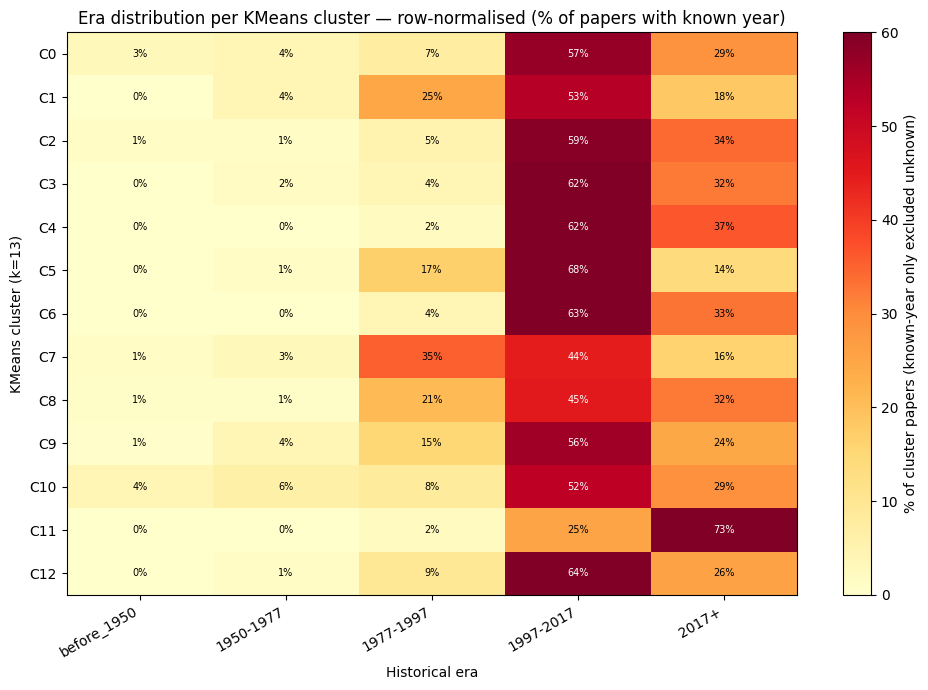

Saved: kmeans_era_heatmap.png


In [ ]:
# ============================================================
# CLUSTER SEMANTIC LABELS + ERA DISTRIBUTION HEATMAP (k=13)
# Run after cell 15 (paper_clusters.csv must be up to date).
# ============================================================

# ── load data ────────────────────────────────────────────────────────────
cl    = pd.read_csv(GRAPH_DIR / "paper_clusters.csv")
meta  = pd.read_csv(OUTPUT_DIR / "metadata_enriched_after_openalex_year.csv")
meta["filename"] = meta["pdf_file"].str.replace(".pdf", "", regex=False)

def _get_era(y):
    """Execute _get_era."""
    if pd.isna(y): return "unknown_year"
    y = int(y)
    if y < 1950:  return "before_1950"
    if y < 1977:  return "1950-1977"
    if y < 1997:  return "1977-1997"
    if y < 2017:  return "1997-2017"
    return "2017+"

meta["era"] = meta["crossref_year"].apply(_get_era)
cl = cl.merge(meta[["filename", "era"]], on="filename", how="left")
cl["era"] = cl["era"].fillna("unknown_year")

# ── keywords ─────────────────────────────────────────────────────────────
kw_df = pd.read_csv(KW_DIR / "keywords_normalized_deduplicated_no_stopwords.csv")
KW_COL = "keywords_without_stopwords"

def _parse_kw(raw):
    """Execute _parse_kw."""
    if pd.isna(raw): return []
    items = ast.literal_eval(raw) if isinstance(raw, str) else raw
    return [(str(k).strip(), float(s)) for k, s in items if str(k).strip()]

kw_lookup = {row["filename"]: _parse_kw(row.get(KW_COL)) for _, row in kw_df.iterrows()}

cluster_keywords = defaultdict(lambda: defaultdict(float))
for _, row in cl.iterrows():
    for kw, s in kw_lookup.get(row["filename"], []):
        cluster_keywords[row["cluster"]][kw] += s

# ── build labels table ───────────────────────────────────────────────────
ERA_ORDER = ["before_1950", "1950-1977", "1977-1997", "1997-2017", "2017+", "unknown_year"]
rows = []
for cid in sorted(cl["cluster"].unique()):
    sub  = cl[cl["cluster"] == cid]
    size = len(sub)
    top5 = sorted(cluster_keywords[cid].items(), key=lambda x: x[1], reverse=True)[:5]
    top3 = " / ".join(kw for kw, _ in top5[:3])

    known     = sub[sub["era"] != "unknown_year"]["era"]
    era_dist  = known.value_counts(normalize=True)
    dom_era   = era_dist.idxmax() if len(era_dist) else "N/A"
    ent       = round(entropy(era_dist), 3) if len(era_dist) else 0.0
    unk_pct   = round((sub["era"] == "unknown_year").sum() / size * 100, 1)

    rows.append({
        "cluster":        cid,
        "size":           size,
        "label":          top3,
        "top_keywords":   "; ".join(kw for kw, _ in top5),
        "dominant_era":   dom_era,
        "era_entropy":    ent,
        "pct_unknown":    unk_pct,
    })

labels_df = pd.DataFrame(rows)
labels_df.to_csv(GRAPH_DIR / "kmeans_cluster_labels.csv", index=False)
print("Saved: kmeans_cluster_labels.csv")
print(labels_df[["cluster","size","label","dominant_era","era_entropy","pct_unknown"]].to_string(index=False))

# ── era distribution heatmap ─────────────────────────────────────────────
ERA_PLOT = ["before_1950", "1950-1977", "1977-1997", "1997-2017", "2017+"]
heat = pd.crosstab(cl["cluster"], cl["era"])
heat = heat.reindex(columns=[e for e in ERA_PLOT if e in heat.columns], fill_value=0)
heat_pct = heat.div(heat.sum(axis=1), axis=0) * 100  # row-normalised %

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(heat_pct.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=60)
plt.colorbar(im, ax=ax, label="% of cluster papers (known-year only excluded unknown)")

# annotate
for r in range(heat_pct.shape[0]):
    for c in range(heat_pct.shape[1]):
        val = heat_pct.values[r, c]
        ax.text(c, r, f"{val:.0f}%", ha="center", va="center",
                fontsize=7, color="black" if val < 40 else "white")

ax.set_xticks(range(len(ERA_PLOT)))
ax.set_xticklabels(ERA_PLOT, rotation=30, ha="right")
ax.set_yticks(range(len(heat_pct)))
ax.set_yticklabels([f"C{int(cid)}" for cid in heat_pct.index])
ax.set_xlabel("Historical era")
ax.set_ylabel("KMeans cluster (k=13)")
ax.set_title("Era distribution per KMeans cluster — row-normalised (% of papers with known year)")

plt.tight_layout()
plt.savefig(GRAPH_DIR / "kmeans_era_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: kmeans_era_heatmap.png")

Assign semantic labels to KMeans clusters and produce the era-distribution heatmap (row-normalised %).

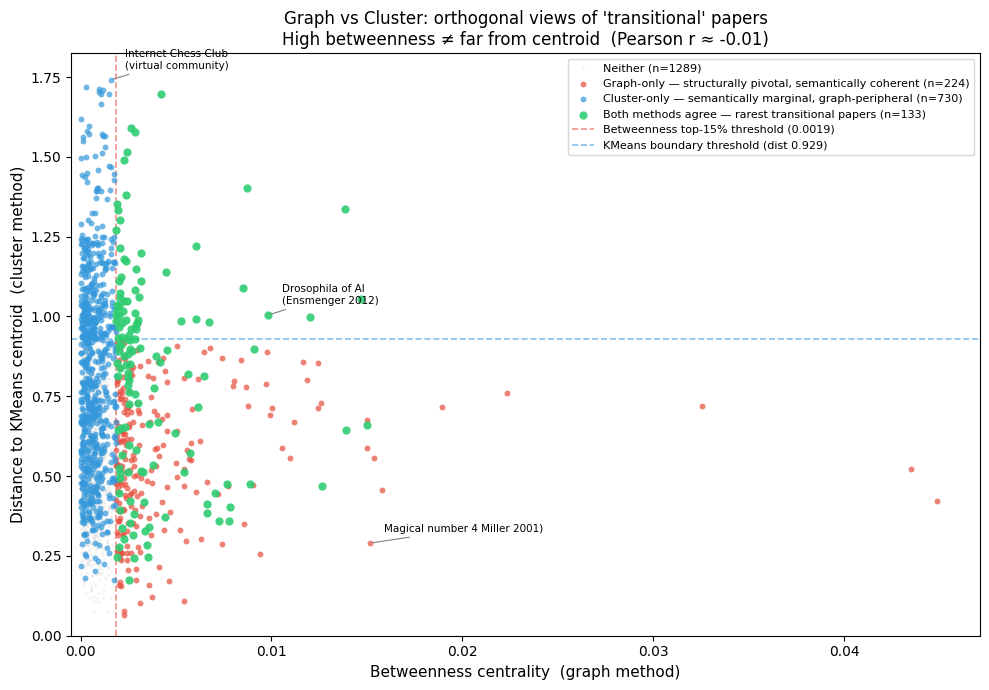

Saved: comparison_betweenness_vs_centroid.png

=== Per-category stats ===
graph_only       n= 224  betw_mean=0.00468  dist_mean=0.556
cluster_only     n= 730  betw_mean=0.00068  dist_mean=0.828
both             n= 133  betw_mean=0.00384  dist_mean=0.822
neither          n=1289  betw_mean=0.00068  dist_mean=0.570


In [ ]:
# ============================================================
# COMPARISON PLOT: betweenness vs distance-to-centroid
# Shows the orthogonality of graph vs cluster methods
# ============================================================

# ── load ─────────────────────────────────────────────────────────────────
_papers = pd.read_csv(GRAPH_DIR / "graph_metrics_full.csv")
_papers = _papers[_papers["type"] == "Paper"].copy()
_cent   = pd.read_csv(GRAPH_DIR / "rq2_centroid_distances.csv")
_hdb    = pd.read_csv(GRAPH_DIR / "rq2_paper_clusters_hdbscan.csv")
_meta   = pd.read_csv(OUTPUT_DIR / "metadata_enriched_after_openalex_year.csv")
_meta["filename"] = _meta["pdf_file"].str.replace(".pdf", "", regex=False)

_df = _papers.merge(_cent[["filename","dist_to_centroid","is_boundary"]]
                    .rename(columns={"filename":"node"}), on="node", how="left")
_df = _df.merge(_hdb[["filename","hdbscan_cluster"]]
                .rename(columns={"filename":"node"}), on="node", how="left")
_df = _df.merge(_meta[["filename","original_title"]].rename(columns={"filename":"node"}),
                on="node", how="left")
                 
# ── classify ─────────────────────────────────────────────────────────────
_btw_thresh = _df["betweenness"].quantile(0.85)
_df["graph_t"]   = _df["betweenness"] >= _btw_thresh
_df["cluster_t"] = (_df["is_boundary"] == True) | (_df["hdbscan_cluster"] == -1)

def _cat(r):
    """Execute _cat."""
    if r["graph_t"] and r["cluster_t"]:  return "both"
    if r["graph_t"]:                      return "graph_only"
    if r["cluster_t"]:                    return "cluster_only"
    return "neither"

_df["category"] = _df.apply(_cat, axis=1)

# ── plot ─────────────────────────────────────────────────────────────────
COLORS = {
    "neither":      ("#cccccc", 0.25, 4,  "Neither (n={})"),
    "graph_only":   ("#e74c3c", 0.70, 18, "Graph-only — structurally pivotal, semantically coherent (n={})"),
    "cluster_only": ("#3498db", 0.70, 18, "Cluster-only — semantically marginal, graph-peripheral (n={})"),
    "both":         ("#2ecc71", 0.90, 35, "Both methods agree — rarest transitional papers (n={})"),
}

fig, ax = plt.subplots(figsize=(10, 7))

for cat, (color, alpha, size, label) in COLORS.items():
    sub = _df[_df["category"] == cat]
    ax.scatter(sub["betweenness"], sub["dist_to_centroid"],
               c=color, alpha=alpha, s=size, linewidths=0,
               label=label.format(len(sub)), zorder=3 if cat != "neither" else 2)

# ── add threshold lines ───────────────────────────────────────────────────
_cent_thresh = _df[_df["is_boundary"] == True]["dist_to_centroid"].min()
ax.axvline(_btw_thresh, color="#e74c3c", linewidth=1.2, linestyle="--", alpha=0.6,
           label=f"Betweenness top-15% threshold ({_btw_thresh:.4f})")
ax.axhline(_cent_thresh, color="#3498db", linewidth=1.2, linestyle="--", alpha=0.6,
           label=f"KMeans boundary threshold (dist {_cent_thresh:.3f})")

# ── annotate a few named examples ────────────────────────────────────────
ANNOTATE = {
    "graph_only": [
        ("The magical number 4 in short-term memory", "Magical number 4 Miller 2001)"),
("Is chess the drosophila of artificial intelligence? A social history of an algorithm", "Drosophila of AI\n(Ensmenger 2012)"),
    ],
    "cluster_only": [
        ("A Framework for Virtual Community Business Success: The Case of the Internet Chess Club",
         "Internet Chess Club\n(virtual community)"),
    ],
}

_title_map = _df.set_index("original_title")

for cat, examples in ANNOTATE.items():
    for title, label in examples:
        matches = _df[_df["original_title"].astype(str).str.contains(title[:40], na=False)]
        if matches.empty:
            continue
        row = matches.iloc[0]
        ax.annotate(
            label,
            xy=(row["betweenness"], row["dist_to_centroid"]),
            xytext=(10, 8), textcoords="offset points",
            fontsize=7.5, ha="left",
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
        )

ax.set_xlabel("Betweenness centrality  (graph method)", fontsize=11)
ax.set_ylabel("Distance to KMeans centroid  (cluster method)", fontsize=11)
ax.set_title(
    "Graph vs Cluster: orthogonal views of 'transitional' papers\n"
    "High betweenness ≠ far from centroid  (Pearson r ≈ {:.2f})".format(
        _df["betweenness"].corr(_df["dist_to_centroid"])),
    fontsize=12,
)
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(left=-0.0005)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(GRAPH_DIR / "comparison_betweenness_vs_centroid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: comparison_betweenness_vs_centroid.png")

# ── print summary stats per category ─────────────────────────────────────
print("\n=== Per-category stats ===")
for cat in ["graph_only","cluster_only","both","neither"]:
    sub = _df[_df["category"] == cat]
    print(f"{cat:15s}  n={len(sub):4d}  "
          f"betw_mean={sub['betweenness'].mean():.5f}  "
          f"dist_mean={sub['dist_to_centroid'].mean():.3f}")